In [ ]:

# Install libraries if missing--

!pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.5 MB/s eta 0:00:00


# Energy Consumption

In [ ]:
# Importing Required libraries

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from pmdarima.arima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy import stats
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Loading the data

from google.colab import files

uploaded = files.upload()

Saving energydata_complete.csv to energydata_complete.csv


### Attribute Information:

#### Attribute	Description	Units

Date	time	year-month-day hour:minute:second

Appliances	energy use	in Wh

lights	energy use of light fixtures in the house	in Wh

T1	Temperature in kitchen area	in Celsius

RH_1	Humidity in kitchen area	in %

T2	Temperature in living room area	in Celsius

RH_2	Humidity in living room area	in %

T3	Temperature in laundry room area

RH_3	Humidity in laundry room area	in %

T4	Temperature in office room	in Celsius

RH_4	Humidity in office room	in %

T5	Temperature in bathroom	in Celsius

RH_5	Humidity in bathroom	in %

T6	Temperature outside the building (north side)	in Celsius

RH_6	Humidity outside the building (north side)	in %

T7	Temperature in ironing room	in Celsius

RH_7	Humidity in ironing room	in %

T8	Temperature in teenager room 2	in Celsius

RH_8	Humidity in teenager room 2	in %

T9	Temperature in parents room	in Celsius

RH_9	Humidity in parents room	in %

To	Temperature outside (from Chievres weather station)	in Celsius

Pressure	(from Chievres weather station)	in mm Hg

RH_out	Humidity outside (from Chievres weather station)	in %

Wind speed	(from Chievres weather station)	in m/s

Visibility	(from Chievres weather station)	in km

Tdewpoint	(from Chievres weather station)	Â °C

rv1	Random variable 1	nondimensional

rv2	Random variable 2	nondimensional

In [ ]:
df = pd.read_csv("energydata_complete.csv")
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
print("shape of the data: ", df.shape)

print("Data types info: ", df.dtypes)

shape of the data:  (19735, 29)
Data types info:  date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object


In [ ]:
# Check for duplicates
print(df.duplicated().sum())

0


In [ ]:
df.isnull().sum() #checking null values

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [ ]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


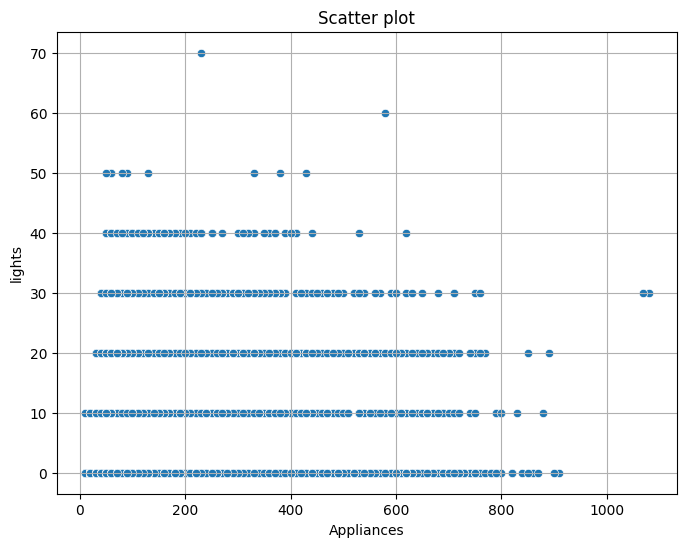

In [ ]:
# Scatter plot of T2 vs T6
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Appliances", y="lights", data=df)
plt.xlabel("Appliances")
plt.ylabel("lights")
plt.grid(True)
plt.title("Scatter plot")
plt.show()


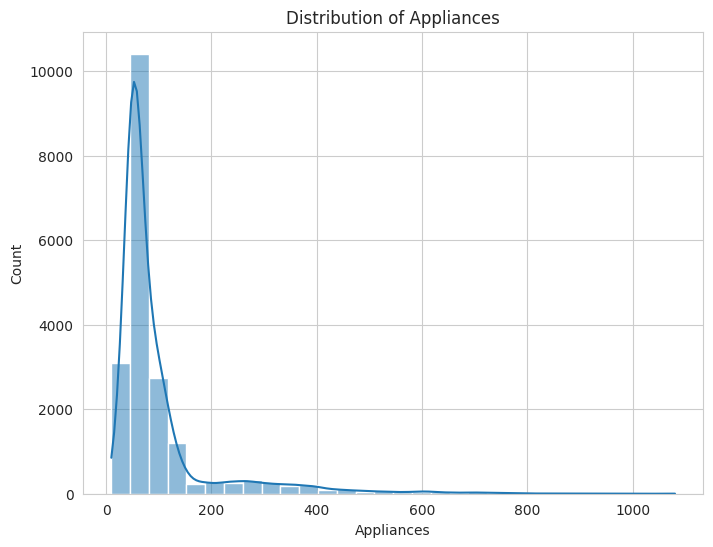

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Histogram of Appliances column
plt.figure(figsize=(8, 6))
sns.histplot(df["Appliances"], bins=30, kde=True)
plt.xlabel("Appliances")
plt.title("Distribution of Appliances")
plt.show()


In [ ]:
# Assuming your DataFrame has a column named 'Date' that contains datetime values, you can set it as the index.
df['date'] = pd.to_datetime(df['date'])  # Convert the 'Date' column to datetime
df.set_index('date', inplace=True)  # Set it as the index

# Now you can proceed with your code as you've originally written it.

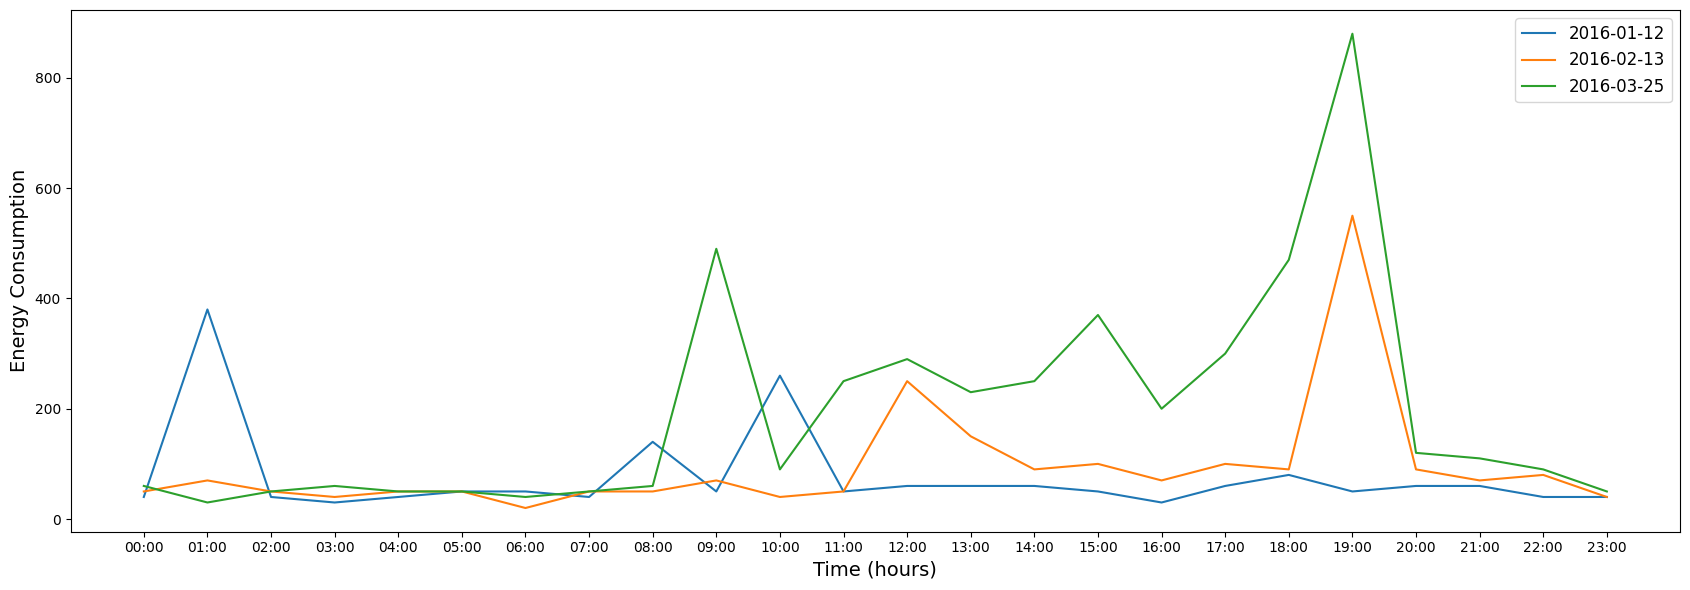

In [ ]:
# Specify the dates you want to plot
selected_dates = ['2016-01-12', '2016-02-13', '2016-03-25']

# Create a figure and axis
fig, ax = plt.subplots(figsize=(17, 6))

# Initialize lists to store the data for each date
energy_data = []

# Iterate through the selected dates and extract energy consumption data
for date in selected_dates:
    daily_energy_consumption = df[df.index.date == pd.to_datetime(date).date()]['Appliances']
    energy_data.append(daily_energy_consumption)

# Plot each date's energy consumption separately
for i, date in enumerate(selected_dates):
    # Extract the time in hours from the datetime index
    times = [t.strftime('%H:%M') for t in energy_data[i].index]

    # Create a list of indices to show only hours (every 6th index)
    hour_indices = list(range(0, len(times), 6))

    # Select the times and energy data at the hour indices
    times = [times[idx] for idx in hour_indices]
    consumption = [energy_data[i].iloc[idx] for idx in hour_indices]

    ax.plot(times, consumption, label=f'{date}')

# Set labels and title
ax.set_xlabel('Time (hours)', fontsize=14)
ax.set_ylabel('Energy Consumption', fontsize = 14)
# ax.set_title('Energy Consumption for Selected Dates')

# Add a legend
ax.legend(fontsize=12)

# Show the plot
# plt.xticks(rotation=90, fontsize = 14)  # Rotate x-axis labels for better visibility
# plt.yticks(
plt.tight_layout()
plt.show()


From the histogram, we can see that the distribution of "Appliances" column is highly skewed to the right, which further confirms the presence of outliers.

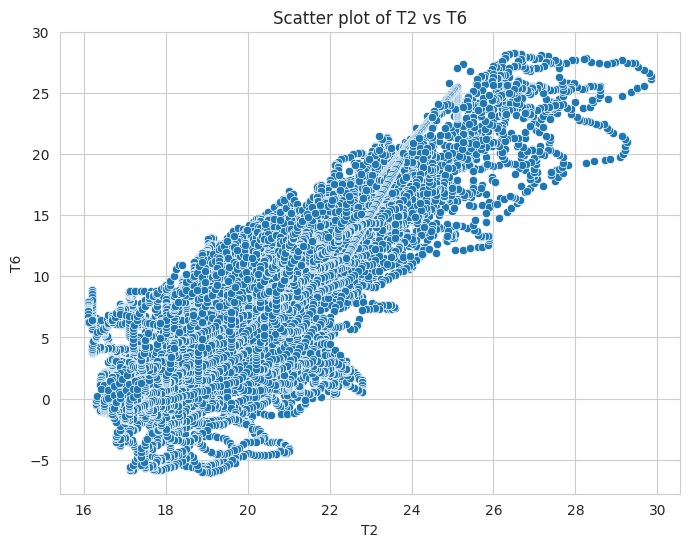

In [ ]:
# Scatter plot of T2 vs T6
plt.figure(figsize=(8, 6))
sns.scatterplot(x="T2", y="T6", data=df)
plt.xlabel("T2")
plt.ylabel("T6")
plt.title("Scatter plot of T2 vs T6")
plt.show()

In [ ]:
# plt.figure(figsize = (4,4))
# sns.pairplot(df, hue = 'Appliances')
# plt.show()


In [ ]:
correlation_matrix = df.corr()

In [ ]:
plt.figure(figsize = (12, 10)) #Figure size
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()


The scatter plot shows a linear relationship between T2 and T6, indicating that they are highly correlated.

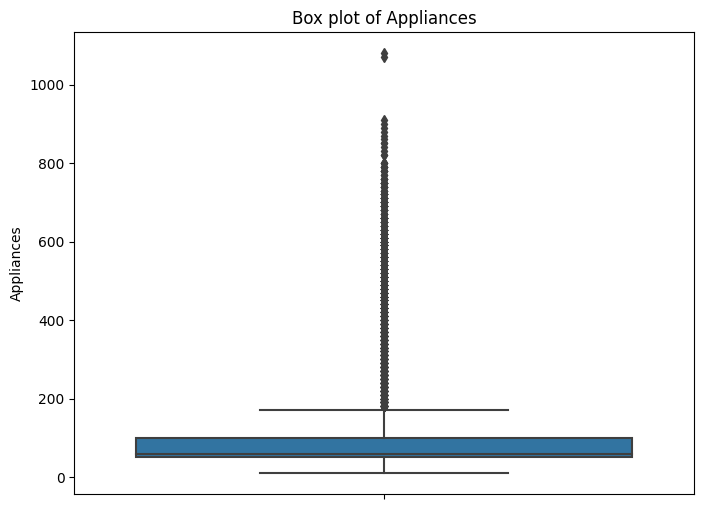

In [ ]:
# Box plot of Appliances column
plt.figure(figsize=(8, 6))
sns.boxplot(y="Appliances", data=df)
plt.ylabel("Appliances")
plt.title("Box plot of Appliances")
plt.show()

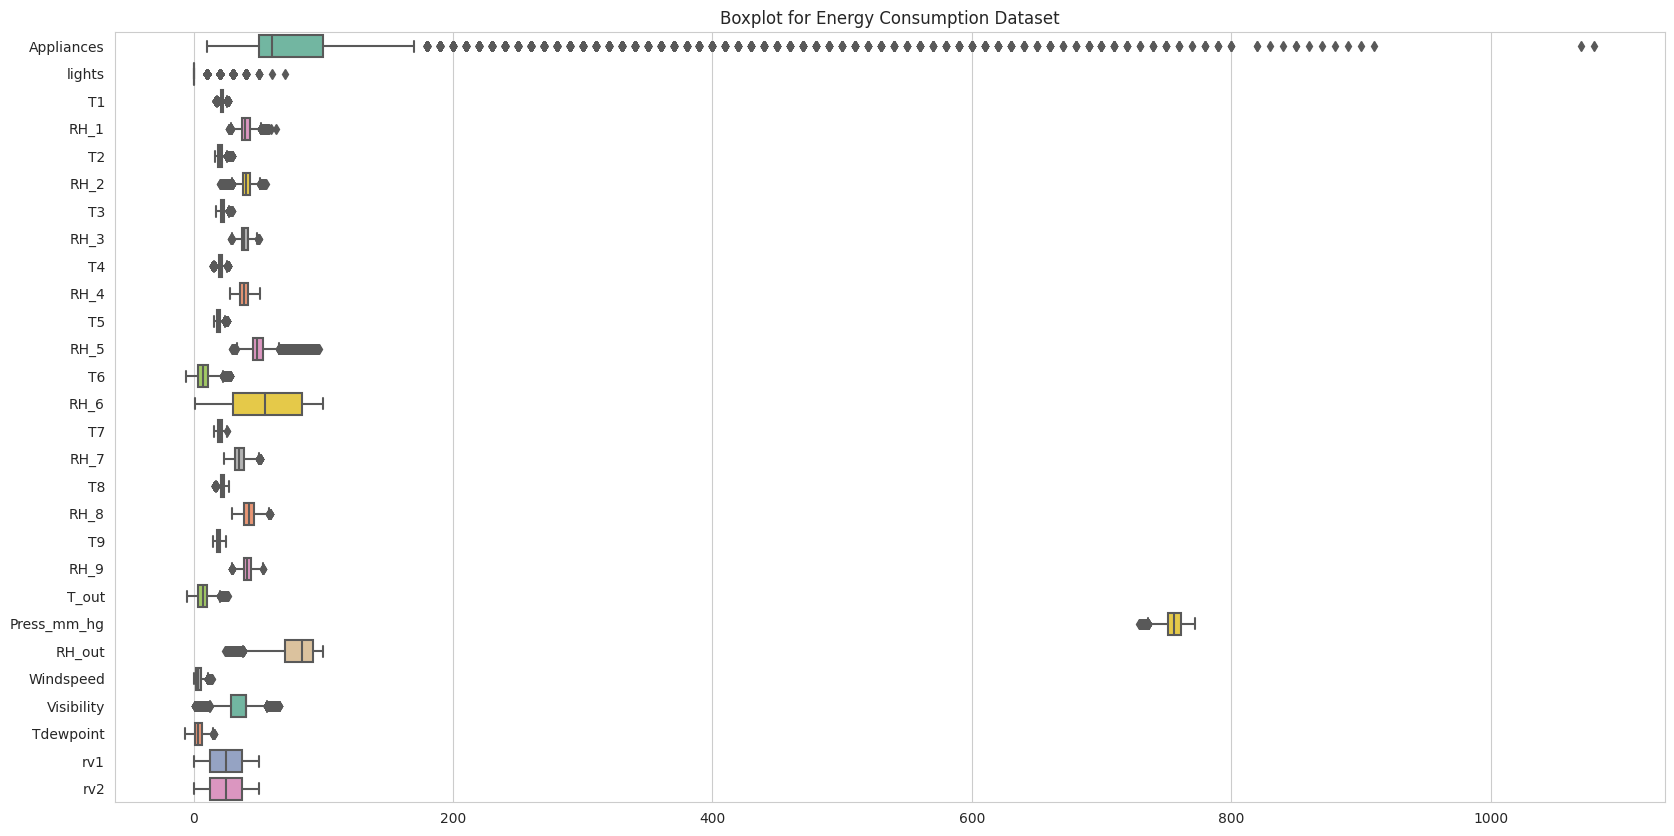

In [ ]:
# Generate boxplots to detect outliers
plt.figure(figsize=(20, 10))
sns.boxplot(data=df, orient="h", palette="Set2")
plt.title("Boxplot for Energy Consumption Dataset")
plt.show()


In [ ]:
df.shape # data is fine till now

(19735, 29)

From the boxplot, we can see that there are outliers in some columns. we need to be careful while removing these outliers as they may be valid data points.

Let's try using the z-score method to remove outliers. Z-score is a measure of how many standard deviations a data point is from the mean.

We will calculate the z-scores for each data point and remove any data point that has a z-score greater than 3 or less than -3.

In [ ]:
# # Defining a function to remove outliers using z-score
# def remove_outliers_zscore(df, cols):
#     for col in cols:
#         z = np.abs(stats.zscore(df[col]))
#         df = df[(z < 3)]
#     return df

# # Remove outliers using z-score
# cols = ['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']
# df = remove_outliers_zscore(df, cols)


In [ ]:
df.shape #outliers removed

(17106, 29)

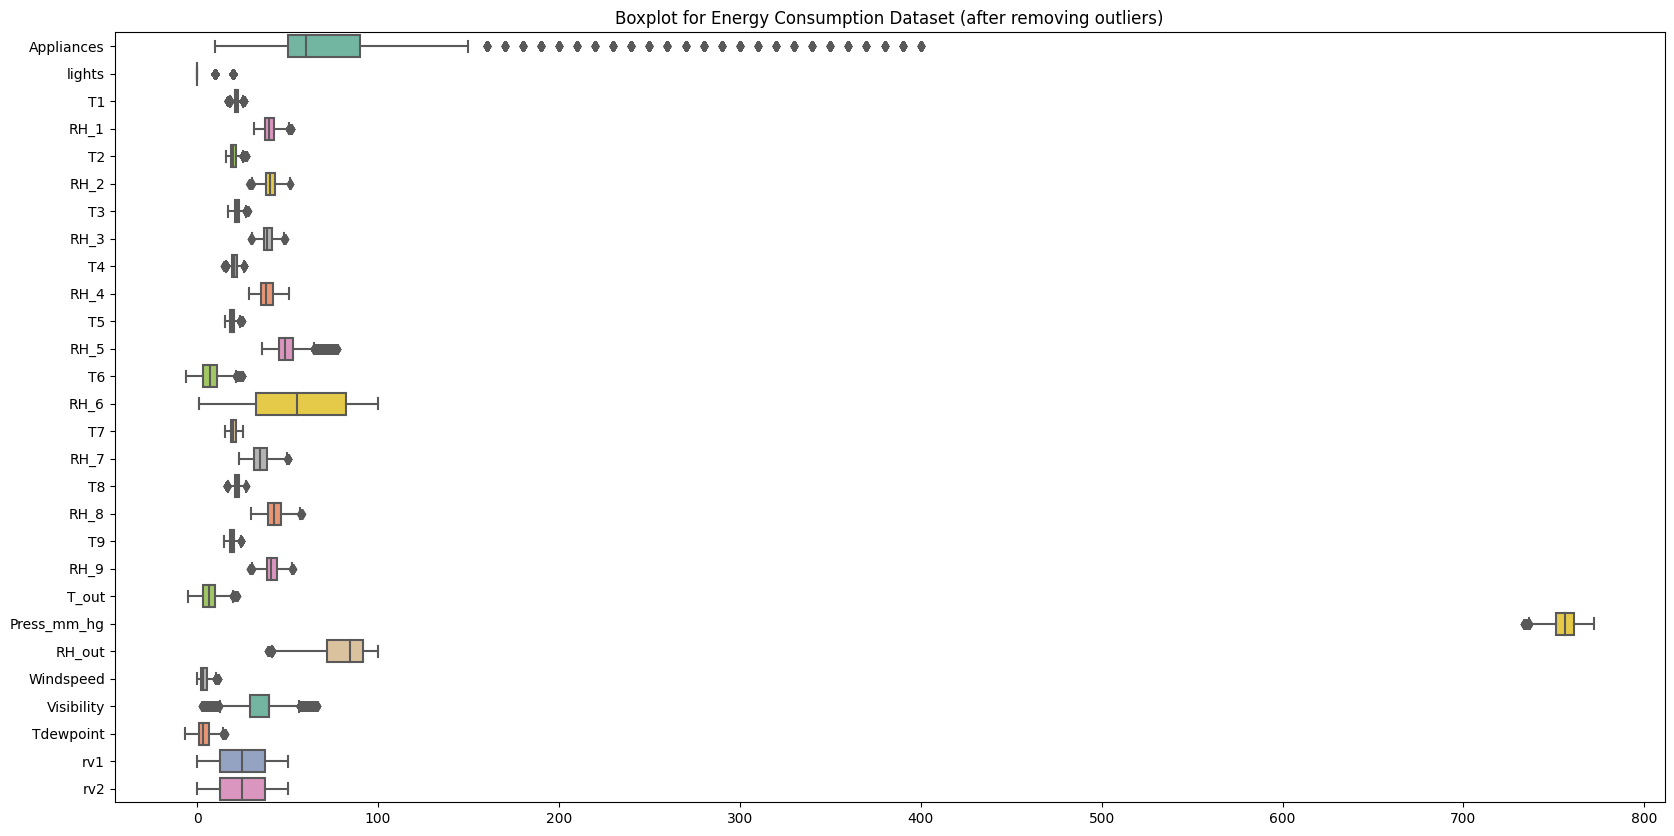

In [ ]:
# Generate boxplots to confirm that outliers have been removed
plt.figure(figsize=(20, 10))
sns.boxplot(data=df, orient="h", palette="Set2")
plt.title("Boxplot for Energy Consumption Dataset (after removing outliers)")
plt.show()

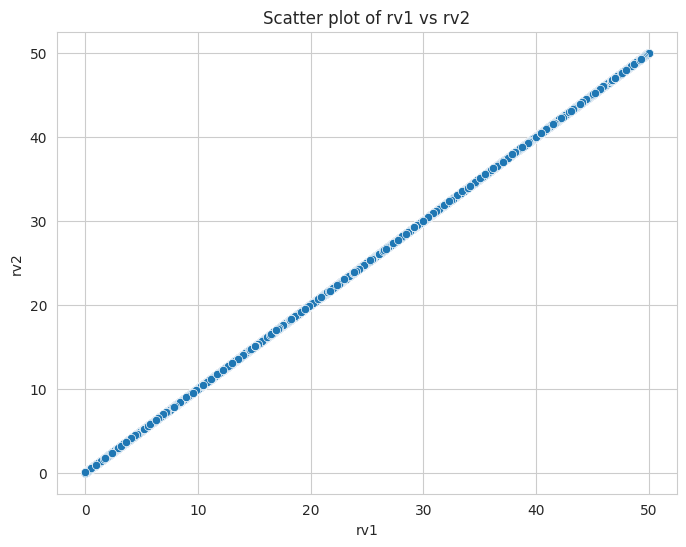

In [ ]:
## Checking linear relationship between columns for taking the target variable--

# Scatter plot of T2 vs T6
plt.figure(figsize=(8, 6))
sns.scatterplot(x="rv1", y="rv2", data=df)
plt.xlabel("rv1")
plt.ylabel("rv2")
plt.title("Scatter plot of rv1 vs rv2")
plt.show()


We can see that the outliers have been removed from the dataset.

In [ ]:
# Extract hour of the day and day of the week from the date column
df['hour'] = pd.to_datetime(df['date']).dt.hour
df['dayofweek'] = pd.to_datetime(df['date']).dt.dayofweek

In [ ]:
# Define independent and dependent variables
X = df[['T2', 'RH_1', 'T_out', 'Press_mm_hg']] # Independent variables
y = df['Appliances'] # Dependent variable

Information of independent variables--

'T2' (Temperature in the living room area): This variable represents the temperature in the living room area. It can be relevant as temperature can affect energy consumption. However, it's important to ensure that the temperature is measured accurately and consistently.

'RH_1' (Humidity in the kitchen area): This variable represents the humidity in the kitchen area. Humidity levels can also have an impact on energy consumption, especially for certain appliances. Make sure the humidity measurements are reliable.

'T_out' (Temperature outside): This variable represents the temperature outside the building. Outdoor temperature can influence the energy consumption of heating or cooling systems in the house. It can be an important variable, especially in regions with extreme weather conditions.

'Press_mm_hg' (Pressure): This variable represents the atmospheric pressure. While it may not have a direct impact on energy consumption, it can be relevant in certain cases, such as for specific HVAC systems that consider pressure differentials.

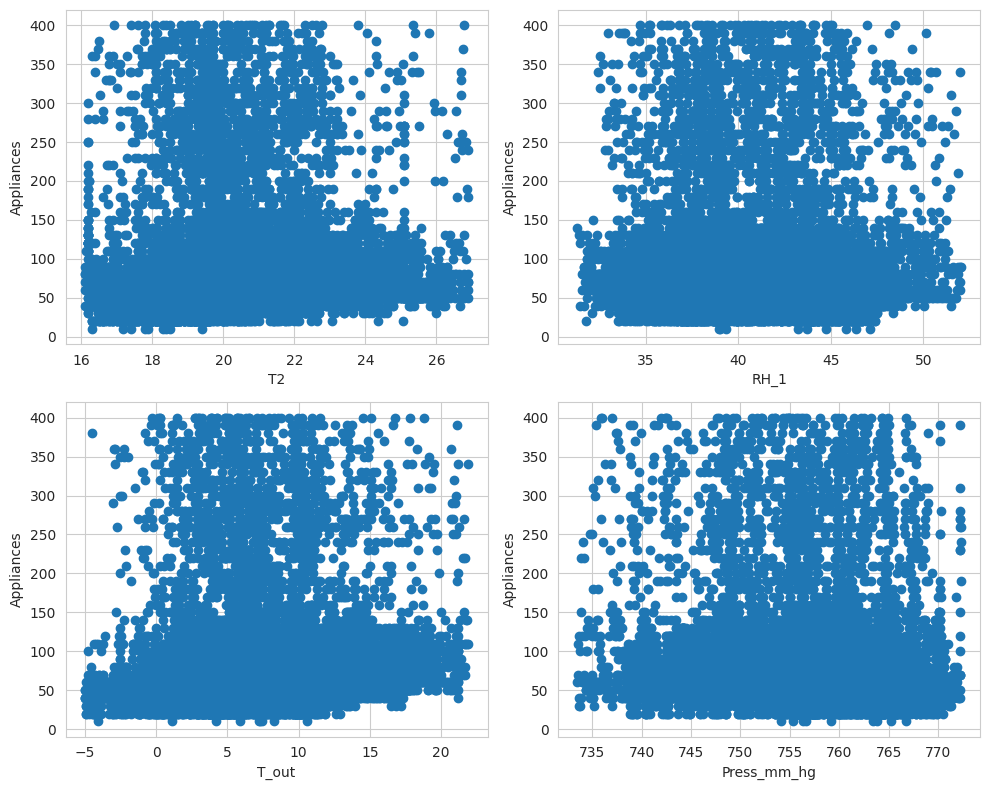

In [ ]:
# Checking linear and non-linear relationship in the dependent and independent variables

# Scatter plots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].scatter(X['T2'], y)
axs[0, 0].set_xlabel('T2')
axs[0, 0].set_ylabel('Appliances')

axs[0, 1].scatter(X['RH_1'], y)
axs[0, 1].set_xlabel('RH_1')
axs[0, 1].set_ylabel('Appliances')

axs[1, 0].scatter(X['T_out'], y)
axs[1, 0].set_xlabel('T_out')
axs[1, 0].set_ylabel('Appliances')

axs[1, 1].scatter(X['Press_mm_hg'], y)
axs[1, 1].set_xlabel('Press_mm_hg')
axs[1, 1].set_ylabel('Appliances')

plt.tight_layout()
plt.show()

# Insights

T2 vs. Appliances: There is a discernible pattern in the scatter plot, indicating a potential non-linear relationship between T2 (average temperature in room 2) and Appliances. As the temperature (T2) increases, there appears to be a general increase in energy consumption (Appliances), suggesting a positive relationship.

RH_1 vs. Appliances: The scatter plot does not exhibit a clear linear or non-linear relationship between RH_1 (humidity in room 1) and Appliances. The data points appear to be scattered without a distinct trend, indicating a weak or no relationship.

T_out vs. Appliances: The scatter plot suggests a non-linear relationship between T_out (average temperature outside) and Appliances. As the outside temperature (T_out) decreases, there seems to be a slight increase in energy consumption (Appliances), indicating a potential non-linear pattern.

Press_mm_hg vs. Appliances: The scatter plot does not reveal a significant linear or non-linear relationship between Press_mm_hg (average pressure in mm Hg) and Appliances. The data points appear to be dispersed randomly, suggesting a weak or no relationship.

In conclusion, based on the scatter plots, it can be inferred that there are potential non-linear relationships between T2 and Appliances, as well as between T_out and Appliances. However, the relationships between RH_1, Press_mm_hg, and Appliances are relatively weak or not apparent. These findings indicate that linear regression models may not be sufficient to capture the complexity of the relationships, and it may be necessary to explore non-linear regression techniques or more advanced modeling approaches to accurately predict Appliances based on these independent variables.

In [ ]:
# Split the data into training and testing sets
#df.drop(['rv1', 'rv2', 'date'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Check multicollinearity

corr_matrix = X.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                   T2      RH_1     T_out  Press_mm_hg
T2           1.000000  0.317417  0.756793    -0.140109
RH_1         0.317417  1.000000  0.416099    -0.290779
T_out        0.756793  0.416099  1.000000    -0.163095
Press_mm_hg -0.140109 -0.290779 -0.163095     1.000000


In [ ]:
#2nd method for multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate the variance inflation factors (VIF)
vif = pd.DataFrame()
vif["Features"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIFs
print("\nVariance Inflation Factors (VIF):")
print(vif)


Variance Inflation Factors (VIF):
      Features         VIF
0           T2  243.259171
1         RH_1  134.423962
2        T_out    7.762192
3  Press_mm_hg  297.456722


Overall, there seems to be some level of correlation between these variables, but it is not extremely high.

So no need for dimensionality reduction..

In [ ]:
# # Scale the data using MinMaxScaler for avoiding multicollinearity issues
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [ ]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
27,2016-01-11 21:30:00,100,20,21.356667,45.826667,20.666667,45.163333,20.390000,46.090000,19.390000,...,16.890000,44.79,5.800000,735.600000,87.500000,6.000000,40.0,3.800000,19.119398,19.119398
28,2016-01-11 21:40:00,100,20,21.390000,45.690000,20.700000,45.060000,20.390000,46.090000,19.426667,...,16.890000,44.70,5.733333,735.666667,87.666667,6.000000,40.0,3.766667,43.484542,43.484542
29,2016-01-11 21:50:00,100,20,21.500000,45.333333,20.700000,44.933333,20.390000,46.060000,19.566667,...,16.890000,44.70,5.666667,735.733333,87.833333,6.000000,40.0,3.733333,17.017450,17.017450
30,2016-01-11 22:00:00,110,20,21.500000,45.126667,20.790000,44.633333,20.390000,46.000000,19.666667,...,16.823333,44.59,5.600000,735.800000,88.000000,6.000000,40.0,3.700000,24.104006,24.104006
31,2016-01-11 22:10:00,400,20,21.533333,44.966667,20.790000,44.360000,20.426667,45.933333,19.600000,...,16.823333,44.53,5.650000,735.883333,87.833333,6.166667,40.0,3.716667,29.978291,29.978291


In [ ]:
df2 = df[['date', 'Appliances']]

In [ ]:
df2.head()

,date,Appliances
0,2016-01-11 17:00:00,60
1,2016-01-11 17:10:00,60
2,2016-01-11 17:20:00,50
3,2016-01-11 17:30:00,50
4,2016-01-11 17:40:00,60


In [ ]:
df2.set_index('date', inplace = True)

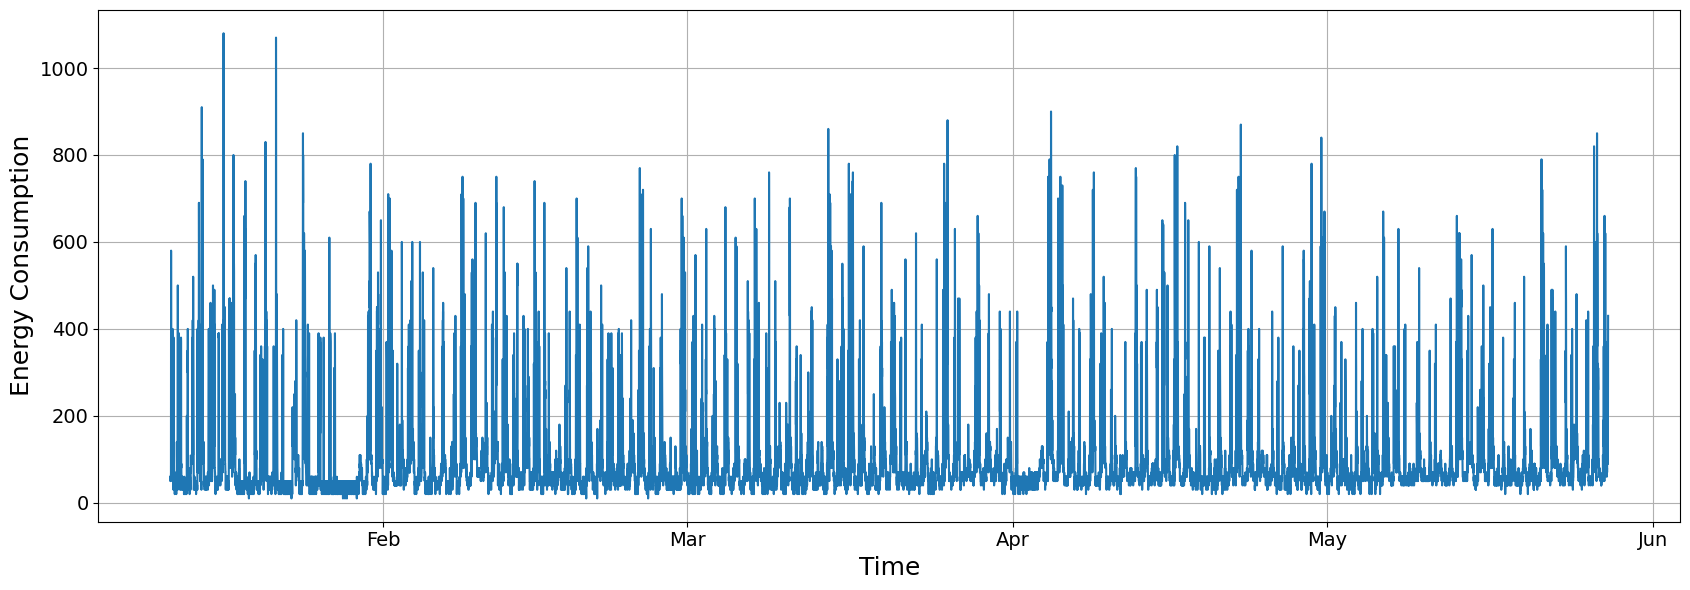

In [ ]:
import matplotlib.dates as mdates

# Convert the 'date' column to datetime format
df2['date'] = pd.to_datetime(df2['date'])

# Plotting the line plot
plt.figure(figsize=(17, 6))  # Adjust the figure size as needed
plt.plot(df2['date'], df2['Appliances'], label='Appliance')
# plt.title('Line Plot of Appliance vs Date')
plt.xlabel('Time', fontsize = 18)
plt.ylabel('Energy Consumption', fontsize = 18)
plt.grid(True)
# plt.legend()

# Format the x-axis ticks with month names
unique_months = df2['date'].dt.month.unique()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval = 1))  # Set ticks for every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month and year

plt.yticks(fontsize = 14)
plt.xticks( fontsize = 14)  # Rotate x-axis labels for readability if necessary
plt.tight_layout()  # Ensure the labels fit within the figure

# Show the plot or save it to a file
plt.show()


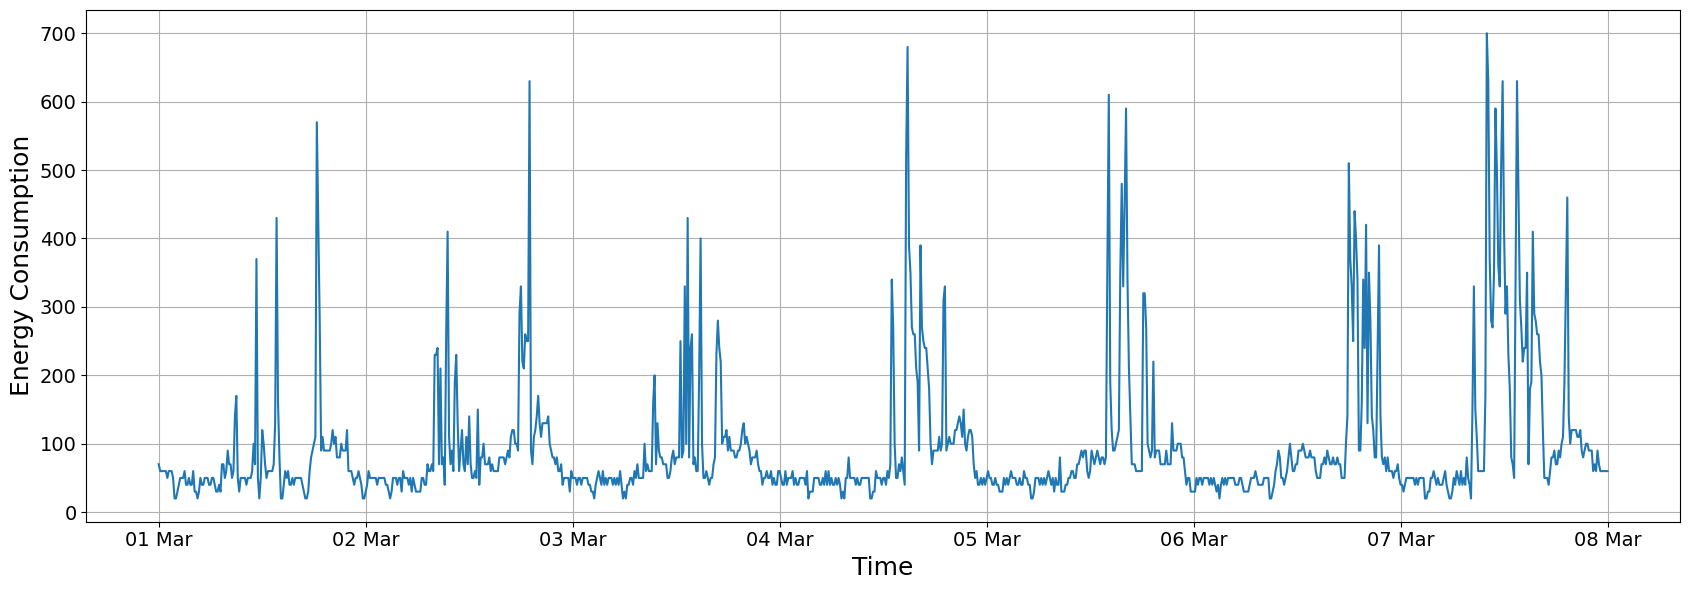

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Assuming 'date' is a datetime column, if not, you may need to convert it to datetime.
# You can use pd.to_datetime(df2['date']) if needed.

# Filter the DataFrame for one week in March
start_date = '2016-03-01'
end_date = '2016-03-08'  # Adjust the end date for one week

filtered_df = df2[(df2['date'] >= start_date) & (df2['date'] <= end_date)]

# Plotting the line plot
plt.figure(figsize=(17, 6))  # Adjust the figure size as needed
plt.plot(filtered_df['date'], filtered_df['Appliances'], label='Appliances')
# plt.title('Line Plot of Appliances for One Week in March')
plt.xlabel('Time', fontsize = 18)
plt.ylabel('Energy Consumption', fontsize = 18)
plt.grid(True)
# plt.legend()

# Format the x-axis ticks with day and month
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # Set ticks for every day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))  # Format as day, abbreviated month, and year

plt.xticks(fontsize = 14)  # Rotate x-axis labels for readability if necessary
plt.yticks(fontsize = 14)
plt.tight_layout()  # Ensure the labels fit within the figure

# Show the plot or save it to a file
plt.show()

In [ ]:
#checking stationarity in the dataset
from statsmodels.tsa.stattools import adfuller

results = adfuller(df2)

In [ ]:
adf_statistics = results[0]
p_value = results[1]
critical_value = results[4]

print("ADF Statistics:",adf_statistics)
print("P value: ",p_value)
print("critical_value:",critical_value)

print()

if p_value <= 0.05:
  print("Reject the null Hypothesis and concluded that data is Stationary")

else:
  print("Fail to Reject the null Hypothesis and concluded that data is Non - Stationary")

ADF Statistics: -21.6163781980362
P value:  0.0
critical_value: {'1%': -3.430681600227742, '5%': -2.8616865555329394, '10%': -2.566848007525354}

Reject the null Hypothesis and concluded that data is Stationary


In [ ]:
decompose_result=seasonal_decompose(x=df2["Appliances"].iloc[-1000:].values,period=24)

<Figure size 3700x2000 with 0 Axes>

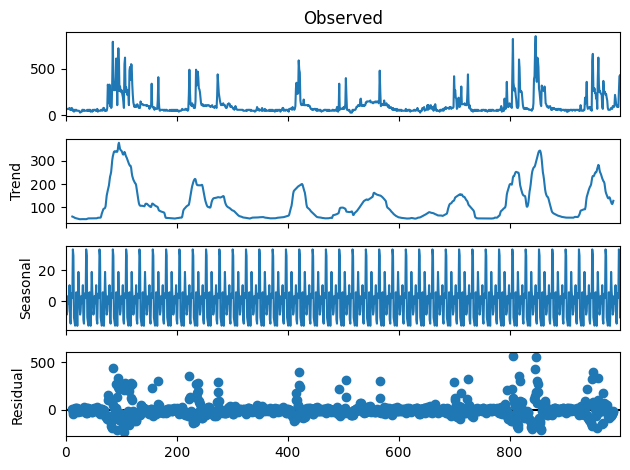

In [ ]:
plt.figure(figsize=(37,20))
decompose_result.plot()
plt.show()

In [ ]:
df2.shape

(19735, 1)

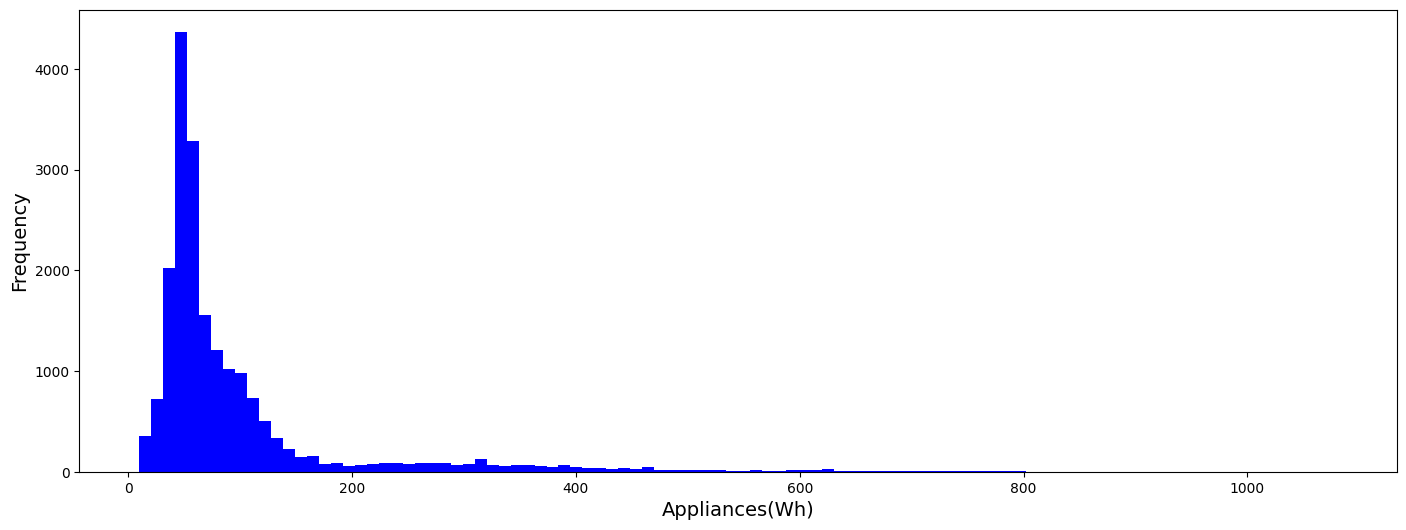

In [ ]:
# Plotting Histogram of the appliances column

plt.figure(figsize=(17, 6))
plt.hist(df2['Appliances'], bins = 100, color = 'blue')
# plt.title("Appliances")
plt.xlabel("Appliances(Wh)", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

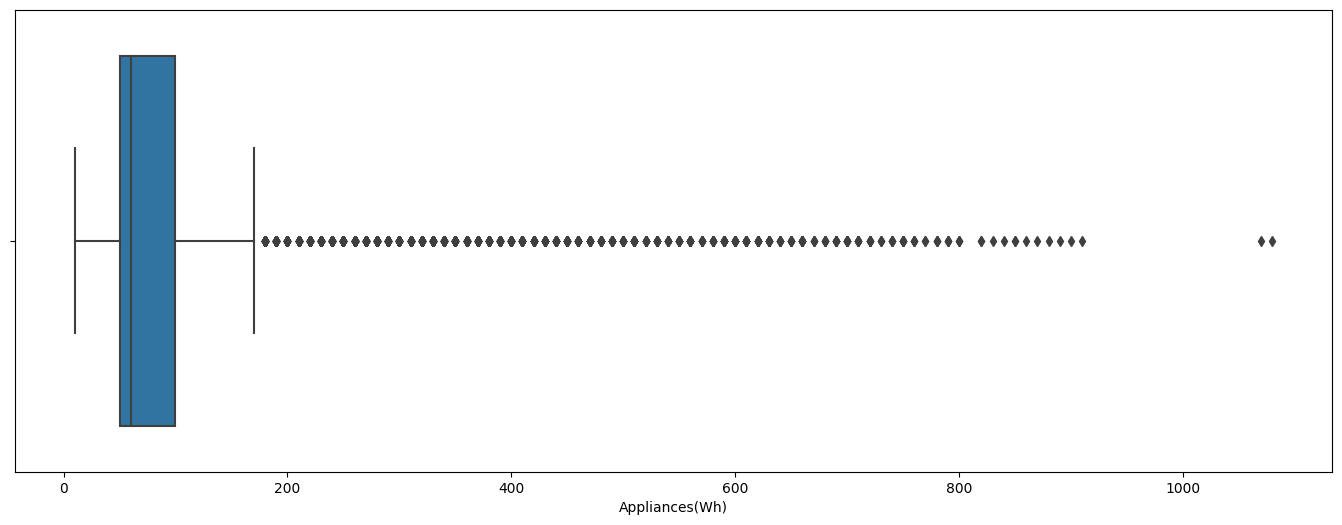

In [ ]:
# Assuming df2 is your DataFrame
plt.figure(figsize=(17, 6))
sns.boxplot(x=df2['Appliances'], orient='h')
plt.xlabel("Appliances(Wh)")
plt.show()


In [ ]:
# # Defining a function to remove outliers using z-score
# def remove_outliers_zscore(df2, cols):
#     for col in cols:
#         z = np.abs(stats.zscore(df2[col]))
#         df2 = df2[(z < 3)]
#     return df2

# # Remove outliers using z-score
# cols = ['Appliances']
# df2 = remove_outliers_zscore(df2, cols)


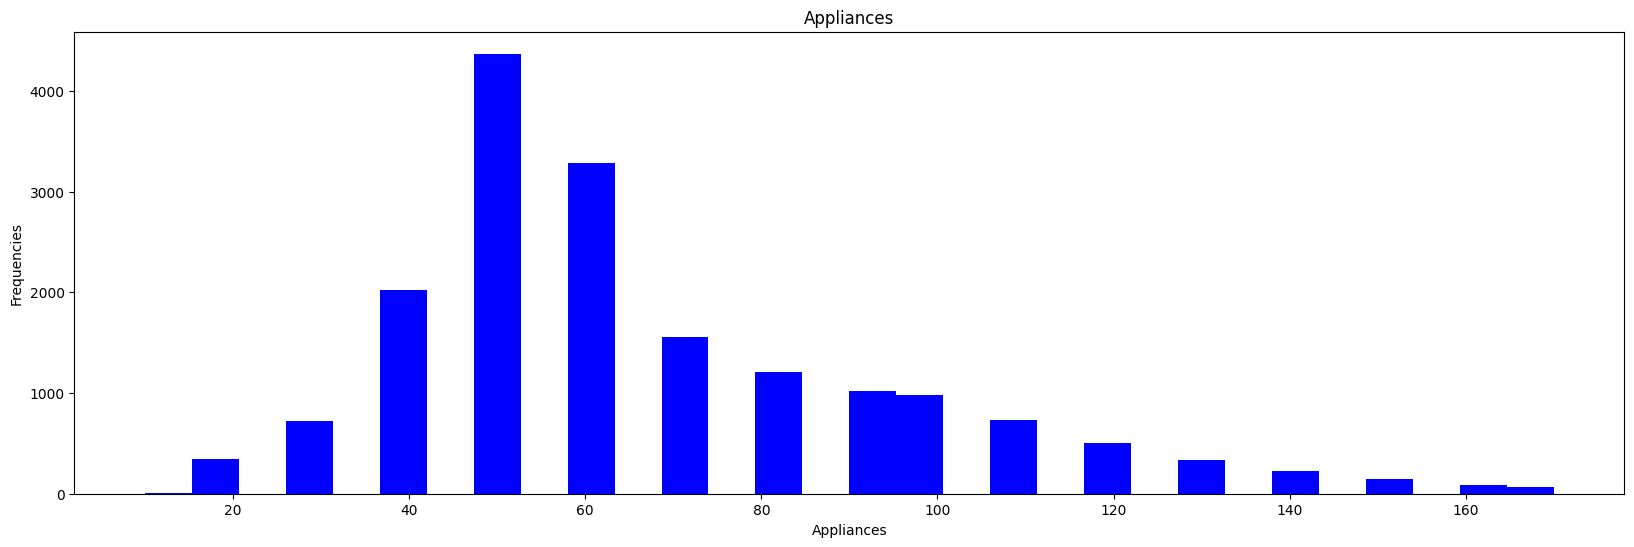

In [ ]:
# Plotting Histogram of the appliances column

plt.figure(figsize=(20, 6))
plt.hist(df2['Appliances'], bins = 30, color = 'blue')
plt.title("Appliances")
plt.xlabel("Appliances")
plt.ylabel("Frequencies")
plt.show()

In [ ]:
# df2 = df[['date', 'Appliances']]

In [ ]:
# df2.set_index('date', inplace = True)

In [ ]:
df2.head()

,Appliances
date,
2016-01-11 17:00:00,60
2016-01-11 17:10:00,60
2016-01-11 17:20:00,50
2016-01-11 17:30:00,50
2016-01-11 17:40:00,60


In [ ]:
q1 = df2['Appliances'].quantile(0.25)
q3 = df2['Appliances'].quantile(0.75)
IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR


In [ ]:
df2 = df2[(df2.Appliances >=lower_bound) & (df2.Appliances <= upper_bound)]

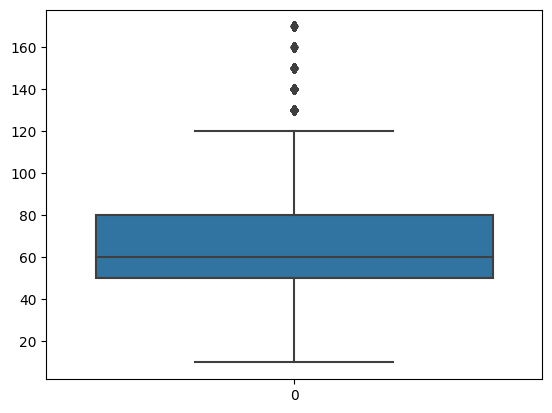

In [ ]:
sns.boxplot(df2['Appliances'])
plt.show()

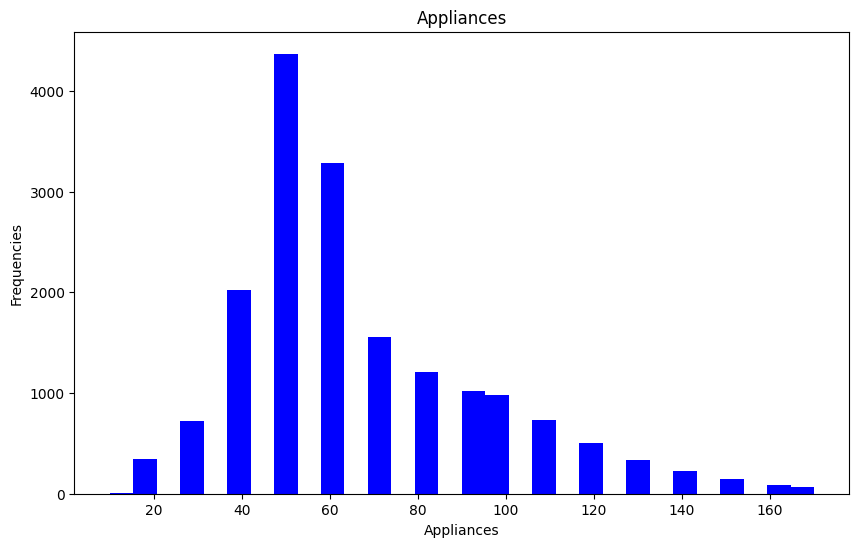

In [ ]:
# Plotting Histogram of the appliances column

plt.figure(figsize=(10, 6))
plt.hist(df2['Appliances'], bins = 30, color = 'blue')
plt.title("Appliances")
plt.xlabel("Appliances")
plt.ylabel("Frequencies")
plt.show()

In [ ]:
train, test  = train_test_split(df2, train_size = 0.70, test_size = 0.3, random_state = 42)

In [ ]:
train.shape

(12317, 1)

In [ ]:
test.shape

(5280, 1)

In [ ]:
test.isnull().sum()

Appliances    0
dtype: int64

In [ ]:
# # Scale the data using MinMaxScaler for avoiding multicollinearity issues
# scaler = MinMaxScaler()
# training_data_scaled = scaler.fit_transform(train)
# test_data_scaled = scaler.fit_transform(test)

In [ ]:
### Without detrending applying ARIMA

# Fit the ARIMA model and find optimal pdq parameters
model = auto_arima(train, seasonal=True, trace=True, suppress_warnings=True)
pdq = model.order

# Print the optimal pdq parameters
print("Optimal pdq:", pdq)

Performing stepwise search to minimize aic


KeyboardInterrupt: ignored

In [ ]:
# parameters = [(2,0,2), (1,0,0), (

In [ ]:
p,d,q = (3, 0, 2)

# Fit the ARIMA model to the detrended data
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

# Obtain the fitted values and residuals
fitted_values_first = model_fit.fittedvalues
residuals = model_fit.resid



In [ ]:
# # Plot the original detrended data and the fitted values
# plt.figure(figsize=(70, 20))
# plt.plot(train, label='Original Data')
# plt.plot(fitted_values, label='Fitted Values')
# plt.xlabel('Time')
# plt.ylabel('Original Data')
# plt.title('ARIMA Model - Fitted Values')
# plt.grid(True)
# plt.legend()
# plt.show()

In [ ]:

fitted_values_results = model_fit.forecast(steps=len(test))
# print(fitted_values.shape)
print(test.shape)
flatten_test = test.values.reshape(-1)
print(flatten_test)
print(flatten_test.shape)

(5280, 1)
[ 20 100  50 ...  40  90  60]
(5280,)


In [ ]:
# # Plot the original detrended data and the fitted values
# plt.figure(figsize=(50, 20))
# plt.plot(df2['Appliances'])
# plt.show()

In [ ]:
import numpy as np

# Given information
fitted_values_results  # Predicted values
test  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
# Calculate Mean Squared Error (MSE) for evaluation
mse = mean_squared_error(flatten_test, fitted_values_results)

# Print the MSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fitted_values_results - flatten_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fitted_values_results - flatten_test) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((test - np.mean(flatten_test)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(flatten_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(flatten_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(flatten_test) - np.min(flatten_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(flatten_test, 75) - np.percentile(flatten_test, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)

Mean Absolute Error: 22.77012013872986
Mean Squared Error: 836.151418813541
Root Mean Squared Error: 28.91628293563232
R-squared: Appliances   -1.229871
dtype: float64
NRMSE-Mean: 0.4304789632620144
NRMSE-SD: 0.9999995841855923
NRMSE-Max-Min: 0.18072676834770202
NRMSE-IQR: 0.9638760978544106


In [ ]:
!pip install arch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 916.4/916.4 kB 7.9 MB/s eta 0:00:00


### Applying GARCH Model

In [ ]:
from arch import arch_model
# Fit the GARCH model
garch_model = arch_model(train, vol='Garch', p=1, q=1)
garch_model_fit = garch_model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 100083.70162981606
Iteration:      2,   Func. Count:     14,   Neg. LLF: 58646.89981523427
Iteration:      3,   Func. Count:     19,   Neg. LLF: 58655.848189495424
Iteration:      4,   Func. Count:     25,   Neg. LLF: 58646.826064583925
Iteration:      5,   Func. Count:     30,   Neg. LLF: 58646.8260505945
Iteration:      6,   Func. Count:     35,   Neg. LLF: 58646.82604986789
Optimization terminated successfully    (Exit mode 0)
            Current function value: 58646.82604986789
            Iterations: 6
            Function evaluations: 35
            Gradient evaluations: 6


In [ ]:
# Forecast using GARCH model
garch_predictions = garch_model_fit.forecast(start=len(test))

In [ ]:
# Extract the mean forecasted values
garch_mean_predictions = garch_predictions.mean.values

In [ ]:
correlation_matrix = df.corr()
app_score = correlation_matrix['Appliances']

In [ ]:
app_score

Appliances     1.000000
lights         0.197278
T1             0.055447
RH_1           0.086031
T2             0.120073
RH_2          -0.060465
T3             0.085060
RH_3           0.036292
T4             0.040281
RH_4           0.016965
T5             0.019760
RH_5           0.006955
T6             0.117638
RH_6          -0.083178
T7             0.025801
RH_7          -0.055642
T8             0.039572
RH_8          -0.094039
T9             0.010010
RH_9          -0.051462
T_out          0.099155
Press_mm_hg   -0.034885
RH_out        -0.152282
Windspeed      0.087122
Visibility     0.000230
Tdewpoint      0.015353
rv1           -0.011145
rv2           -0.011145
Name: Appliances, dtype: float64

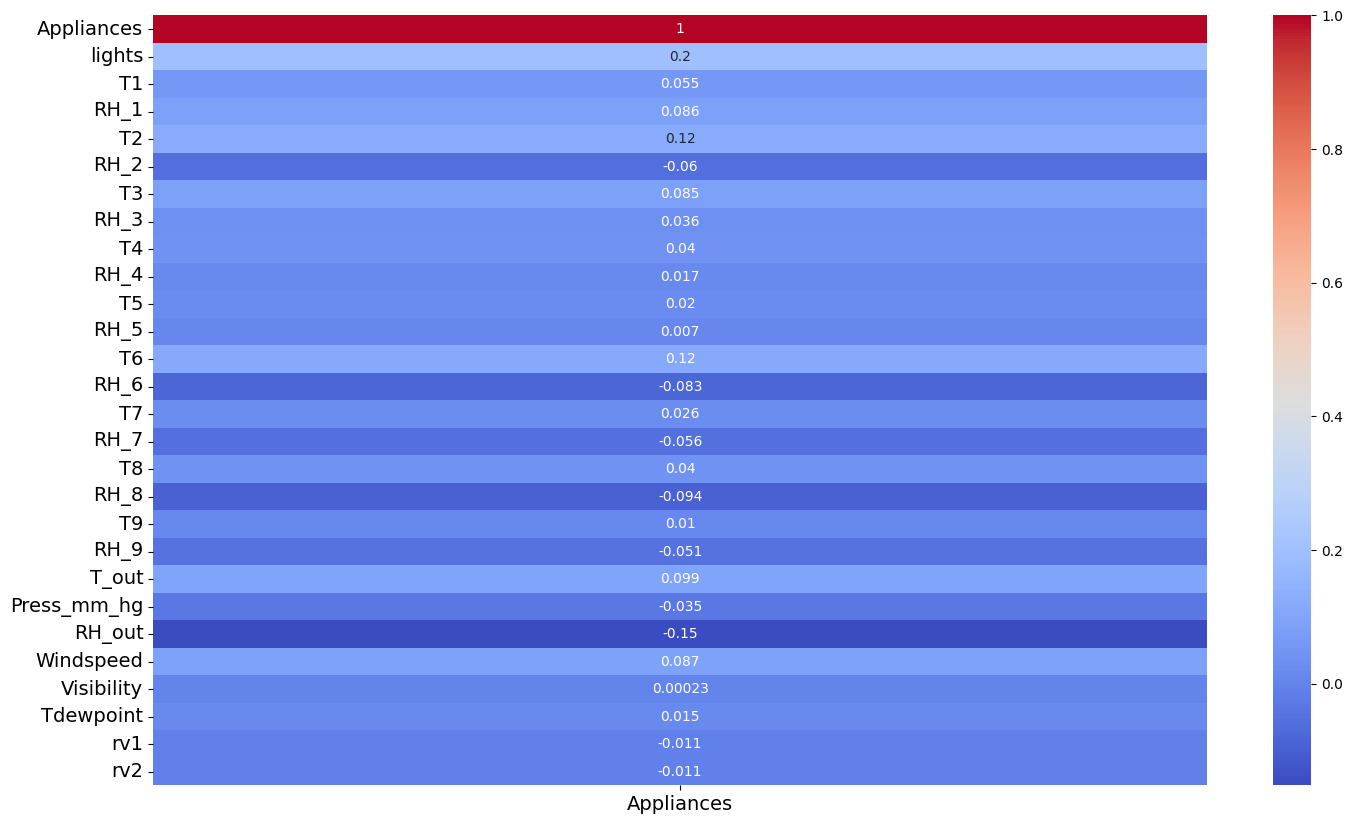

In [ ]:
plt.figure(figsize = (17, 10))
sns.heatmap(app_score.to_frame(),cmap = 'coolwarm', annot = True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [ ]:
df3 = df[["date", "T1", "RH_1", "RH_2", "T3", "RH_6", "RH_7", "RH_8", "RH_9", "RH_out", "T_out", "Windspeed", "Appliances"]]

In [ ]:
df3['date'] = pd.to_datetime(df3['date'])

In [ ]:
df3 = df3.set_index('date')

In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19735 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   T1          19735 non-null  float64
 1   RH_1        19735 non-null  float64
 2   RH_2        19735 non-null  float64
 3   T3          19735 non-null  float64
 4   RH_6        19735 non-null  float64
 5   RH_7        19735 non-null  float64
 6   RH_8        19735 non-null  float64
 7   RH_9        19735 non-null  float64
 8   RH_out      19735 non-null  float64
 9   T_out       19735 non-null  float64
 10  Windspeed   19735 non-null  float64
 11  Appliances  19735 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 2.0 MB


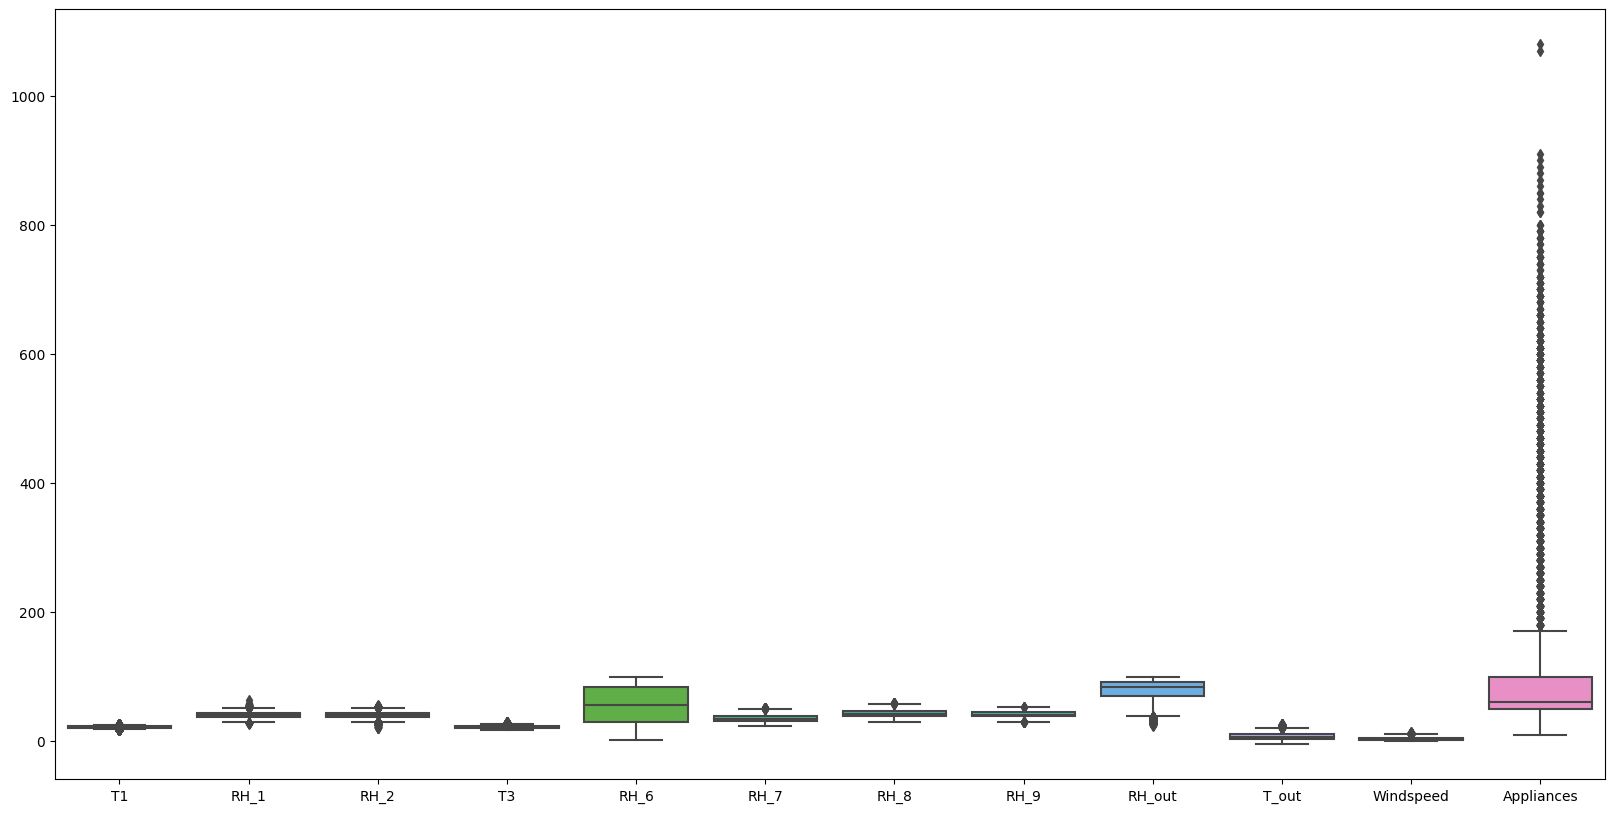

In [ ]:
plt.figure(figsize = (20, 10))
sns.boxplot(data = df3)
plt.show()

In [ ]:
# Treating outliers

q1 = df3['Appliances'].quantile(0.25)
q3 = df3['Appliances'].quantile(0.75)
IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df3 = df3[(df3.Appliances >=lower_bound) & (df3.Appliances <= upper_bound)]

In [ ]:
# y.shape

In [ ]:
X = df3.drop('Appliances', axis = 1)
y = df3['Appliances']

NameError: ignored

In [ ]:
X_train, X_test, y_train, actual_test = train_test_split(X, y, random_state = 42, train_size = 0.7)

In [ ]:
X_train.shape

(12317, 11)

In [ ]:
y_train.shape

(12317,)

In [ ]:
# Scale the data using MinMaxScaler for avoiding multicollinearity issues
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### NEW SYSTEM

In [ ]:
# Scale the data using MinMaxScaler for avoiding multicollinearity issues
scaler = MinMaxScaler()
new_system = scaler.fit_transform(X)
# X_test_scaled = scaler.transform(X_test)

In [ ]:
X_test_scaled

array([[0.1392136 , 0.39486865, 0.5795841 , ..., 0.94260486, 0.26795284,
        0.42857143],
       [0.92561105, 0.57068384, 0.60439219, ..., 0.41280353, 0.88853162,
        0.14285714],
       [0.51115834, 0.35807012, 0.62685842, ..., 0.91611479, 0.27545552,
        0.14285714],
       ...,
       [0.50053135, 0.35193703, 0.59673501, ..., 0.80794702, 0.32154341,
        0.25      ],
       [0.8607864 , 0.59419401, 0.6435239 , ..., 0.34657837, 0.90032154,
        0.47619048],
       [0.48884166, 0.27220689, 0.53843164, ..., 0.83222958, 0.20364416,
        0.14285714]])

# Testing regression models--
  1) Random forest Regression

  2) Decision Tree Regression
  
  3) XGBOOST
  
  4) Linear Regression

In [ ]:
# Fit the linear regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# New system

# Fit the linear regression model
lr = LinearRegression()
lr.fit(new_system, y)

LinearRegression()

In [ ]:
# Evaluate the model on the test set
linear_pred_test = lr.predict(X_test_scaled)
linear_pred_train = lr.predict(X_train_scaled)
linear_pred_newsystem = lr.predict(new_system)
print("Mean Absolute Error:", round(mean_absolute_error(actual_test, linear_pred_test), 2))
print("Mean Squared Error:", round(mean_squared_error(actual_test, linear_pred_test), 2))
print("Root Mean Squared Error:", round(np.sqrt(mean_squared_error(actual_test, linear_pred_test)), 2))
print("R-squared:", round(r2_score(actual_test, linear_pred_test), 2))
print()

### New system hai bhai

print("Mean Absolute Error:", round(mean_absolute_error(y, linear_pred_newsystem), 2))
print("Mean Squared Error:", round(mean_squared_error(y, linear_pred_newsystem), 2))
print("Root Mean Squared Error:", round(np.sqrt(mean_squared_error(y, linear_pred_newsystem)), 2))
print("R-squared:", round(r2_score(y, linear_pred_newsystem), 2))

Mean Absolute Error: 18.68
Mean Squared Error: 638.73
Root Mean Squared Error: 25.27
R-squared: 0.24

Mean Absolute Error: 18.63
Mean Squared Error: 615.52
Root Mean Squared Error: 24.81
R-squared: 0.24


In [ ]:
new_system.shape

(5280,)

In [ ]:
y.shape

(17597,)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor()
random_forest.fit(X_train_scaled, y_train)

RandomForestRegressor()

In [ ]:
rf_pred = random_forest.predict(X_test_scaled)

In [ ]:
# Evaluate the model on the test set
print("Mean Absolute Error:", round(mean_absolute_error(actual_test, rf_pred), 2))
print("Mean Squared Error:", round(mean_squared_error(actual_test, rf_pred), 2))
print("Root Mean Squared Error:", round(np.sqrt(mean_squared_error(actual_test, rf_pred)), 2))
print("R-squared:", round(r2_score(actual_test, rf_pred), 2))

Mean Absolute Error: 11.13
Mean Squared Error: 283.5
Root Mean Squared Error: 16.84
R-squared: 0.66


In [ ]:
from sklearn.tree import DecisionTreeRegressor

Decision_tree = DecisionTreeRegressor()
Decision_tree.fit(X_train_scaled, y_train)

DecisionTreeRegressor()

In [ ]:
Dt_pred = Decision_tree.predict(X_test_scaled)

In [ ]:
# Evaluate the model on the test set
print("Mean Absolute Error:", round(mean_absolute_error(actual_test, Dt_pred), 2))
print("Mean Squared Error:", round(mean_squared_error(actual_test, Dt_pred), 2))
print("Root Mean Squared Error:", round(np.sqrt(mean_squared_error(actual_test, Dt_pred)), 2))
print("R-squared:", round(r2_score(actual_test, Dt_pred), 2))

Mean Absolute Error: 13.66
Mean Squared Error: 470.27
Root Mean Squared Error: 21.69
R-squared: 0.44


In [ ]:
from sklearn.svm import SVR

svr_rbf = SVR(kernel='rbf', C=1e3, gamma=0.1)
svr_lin = SVR(kernel='linear', C=1e3)
svr_poly = SVR(kernel='poly', C=1e3, degree=2)
y_rbf = svr_rbf.fit(X_train_scaled, y_train).predict(X_test_scaled)
y_lin = svr_lin.fit(X_train_scaled, y_train).predict(X_test_scaled)
y_poly = svr_poly.fit(X_train_scaled, y_train).predict(X_test_scaled)

In [ ]:
# Evaluate the model on the test set
print("Mean Absolute Error:", round(mean_absolute_error(actual_test, y_rbf), 2))
print("Mean Squared Error:", round(mean_squared_error(actual_test, y_rbf), 2))
print("Root Mean Squared Error:", round(np.sqrt(mean_squared_error(actual_test, y_rbf)), 2))
print("R-squared:", round(r2_score(actual_test, y_rbf), 2))

Mean Absolute Error: 17.22
Mean Squared Error: 605.79
Root Mean Squared Error: 24.61
R-squared: 0.28


In [ ]:
# Evaluate the model on the test set
print("Mean Absolute Error:", round(mean_absolute_error(actual_test, y_lin), 2))
print("Mean Squared Error:", round(mean_squared_error(actual_test, y_lin), 2))
print("Root Mean Squared Error:", round(np.sqrt(mean_squared_error(actual_test, y_lin)), 2))
print("R-squared:", round(r2_score(actual_test, y_lin), 2))

Mean Absolute Error: 18.43
Mean Squared Error: 664.48
Root Mean Squared Error: 25.78
R-squared: 0.21


In [ ]:
# Evaluate the model on the test set
print("Mean Absolute Error:", round(mean_absolute_error(actual_test, y_poly), 2))
print("Mean Squared Error:", round(mean_squared_error(actual_test, y_poly), 2))
print("Root Mean Squared Error:", round(np.sqrt(mean_squared_error(actual_test, y_poly)), 2))
print("R-squared:", round(r2_score(actual_test, y_poly), 2))

Mean Absolute Error: 17.13
Mean Squared Error: 588.16
Root Mean Squared Error: 24.25
R-squared: 0.3


In [ ]:
import xgboost as xgb

In [ ]:
#Define and Fit XG Boost Regressor Model
reg_model = xgb.XGBRegressor(n_estimators=500)
#Declare Evaluation data
eval_data=[(X_train_scaled, y_train), (X_test_scaled, actual_test)]
reg_model.fit(X_train_scaled, y_train,eval_set=eval_data,early_stopping_rounds=60,verbose=True)

[0]	validation_0-rmse:53.51934	validation_1-rmse:54.00953
[1]	validation_0-rmse:40.86529	validation_1-rmse:41.69723
[2]	validation_0-rmse:32.60104	validation_1-rmse:33.77558
[3]	validation_0-rmse:27.45172	validation_1-rmse:28.92404
[4]	validation_0-rmse:24.27421	validation_1-rmse:25.91173
[5]	validation_0-rmse:22.43515	validation_1-rmse:24.21607
[6]	validation_0-rmse:21.19387	validation_1-rmse:23.11770
[7]	validation_0-rmse:20.41049	validation_1-rmse:22.42407
[8]	validation_0-rmse:19.97247	validation_1-rmse:22.11541
[9]	validation_0-rmse:19.45401	validation_1-rmse:21.71990
[10]	validation_0-rmse:19.07627	validation_1-rmse:21.43871
[11]	validation_0-rmse:18.88277	validation_1-rmse:21.29879
[12]	validation_0-rmse:18.71596	validation_1-rmse:21.19286
[13]	validation_0-rmse:18.58460	validation_1-rmse:21.11492
[14]	validation_0-rmse:18.26545	validation_1-rmse:20.95835
[15]	validation_0-rmse:18.08056	validation_1-rmse:20.83697
[16]	validation_0-rmse:17.85760	validation_1-rmse:20.73179
[17]	va

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=500, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...)

In [ ]:
xg_pred = reg_model.predict(X_test_scaled)

In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(actual_test, xg_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_test, xg_pred)
r2 = r2_score(actual_test, xg_pred)

In [ ]:
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared Score:", r2)

Mean Squared Error (MSE): 312.95800287904177
Root Mean Squared Error (RMSE): 17.69061906432451
Mean Absolute Error (MAE): 12.05490770484462
R-squared Score: 0.6257164245941544


# Applying time series models and neural networks--

  1) ARIMA

  2) GARCH

  3) FNN
  
  4) RNN
  
  5) LSTM

In [ ]:
### ARIMA Model--

### ARIMA ON LINEAR REGRESSION RESULTS

In [ ]:
p,d,q = (3, 0, 2)

# Fit the ARIMA model to the detrended data
model = ARIMA(linear_pred_newsystem, order=(p, d, q))
model_fit = model.fit()

# Obtain the fitted values and residuals
fitted_values = model_fit.fittedvalues
residuals = model_fit.resid

In [ ]:
fitted_values = model_fit.forecast(steps=len(y))
print(fitted_values.shape)

(17597,)


In [ ]:
flatten_test = y.values.reshape(-1)
# print(flatten_test)
print(flatten_test.shape)

(17597,)


In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
test  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
# Calculate Mean Squared Error (MSE) for evaluation
mse = mean_squared_error(flatten_test, fitted_values)

# Print the MSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fitted_values - flatten_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fitted_values - flatten_test) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((test - np.mean(flatten_test)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(flatten_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(flatten_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(flatten_test) - np.min(flatten_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(flatten_test, 75) - np.percentile(flatten_test, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
# print('NRMSE-Mean:', nrmse_mean)
# print('NRMSE-SD:', nrmse_sd)
# print('NRMSE-Max-Min:', nrmse_max_min)
# print('NRMSE-IQR:', nrmse_iqr)

Mean Absolute Error: 22.453106798572506
Mean Squared Error: 811.3892610292702
Root Mean Squared Error: 28.484895313644216
R-squared: Appliances    0.963335
dtype: float64


### ARIMA ON Random forest results

In [ ]:
p,d,q = (3, 0, 2)

# Fit the ARIMA model to the detrended data
model = ARIMA(rf_pred, order=(p, d, q))
model_fit = model.fit()

# Obtain the fitted values and residuals
fitted_values = model_fit.fittedvalues
residuals = model_fit.resid

In [ ]:
fitted_values = model_fit.forecast(steps=len(test))
print(fitted_values.shape)

(5280,)


In [ ]:
flatten_test = test.values.reshape(-1)
# print(flatten_test)
print(flatten_test.shape)

(5280,)


In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
test  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
# Calculate Mean Squared Error (MSE) for evaluation
mse = mean_squared_error(flatten_test, fitted_values)

# Print the MSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fitted_values - flatten_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fitted_values - flatten_test) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((test - np.mean(flatten_test)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(flatten_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(flatten_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(flatten_test) - np.min(flatten_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(flatten_test, 75) - np.percentile(flatten_test, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
# print('NRMSE-Mean:', nrmse_mean)
# print('NRMSE-SD:', nrmse_sd)
# print('NRMSE-Max-Min:', nrmse_max_min)
# print('NRMSE-IQR:', nrmse_iqr)

Mean Absolute Error: 22.615726648929105
Mean Squared Error: 836.5010641705601
Root Mean Squared Error: 28.922328125006814
R-squared: Appliances    0.400572
dtype: float64


### ENSEMBLING THE RESULTS OF LINEAR REGRESSION AND RANDOM FOREST

In [ ]:
Linear regression--

Mean Absolute Error: 18.81
Mean Squared Error: 637.63
Root Mean Squared Error: 25.25
R-squared: 0.24

ARIMA ON Linear Regression --

Mean Absolute Error: 22.653450319528368
Mean Squared Error: 836.3762124805073
Root Mean Squared Error: 28.920169648197213
R-squared: Appliances    0.772463

Random forest --
Mean Absolute Error: 11.11
Mean Squared Error: 282.22
Root Mean Squared Error: 16.8
R-squared: 0.66

ARIMA ON Random forest --

Mean Absolute Error: 22.59670346065846
Mean Squared Error: 836.5964784698377
Root Mean Squared Error: 28.92397756999956
R-squared: Appliances    0.404186


LINEAR REGRESSION + RANDOM FOREST

Mean Absolute Error: 13.766718785749537
Mean Squared Error: 382.3368926664069
Root Mean Squared Error: 19.553436850497842
R-squared: Appliances    0.404186


ARIMA + LINEAR REGRESSION --

Mean Absolute Error: 20.001619752079804
Mean Squared Error: 689.1820805743142
Root Mean Squared Error: 26.252277626413946
R-squared: Appliances   -1.229871

XGBoost + Random forest

Mean Absolute Error: 11.278586903629881
Mean Squared Error: 284.96190574694407
Root Mean Squared Error: 16.880814724027513
R-squared: Appliances   -1.229871

In [ ]:
Ensembled_results = (linear_pred_test + rf_pred)/2

In [ ]:
Ensembled_results

array([48.96611681, 77.21852045, 51.07851905, ..., 55.42834125,
       88.76961696, 59.35895365])

In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
test  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
# Calculate Mean Squared Error (MSE) for evaluation
mse = mean_squared_error(flatten_test, Ensembled_results)

# Print the MSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(Ensembled_results - flatten_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((Ensembled_results - flatten_test) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((test - np.mean(flatten_test)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
#nrmse_mean = rmse / np.mean(flatten_test)

# # Calculate NRMSE-SD
# nrmse_sd = rmse / np.std(flatten_test)

# # Calculate NRMSE-Max-Min
# nrmse_max_min = rmse / (np.max(flatten_test) - np.min(flatten_test))

# # Calculate NRMSE-IQR
# nrmse_iqr = rmse / (np.percentile(flatten_test, 75) - np.percentile(flatten_test, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
# # print('NRMSE-Mean:', nrmse_mean)
# # print('NRMSE-SD:', nrmse_sd)
# # print('NRMSE-Max-Min:', nrmse_max_min)
# # print('NRMSE-IQR:', nrmse_iqr)

Mean Absolute Error: 13.714935241251254
Mean Squared Error: 383.37374506569796
Root Mean Squared Error: 19.579932202786043
R-squared: Appliances    0.400572
dtype: float64


### ENSEMBLING THE RESULTS OF LINEAR REGRESSION AND ARIMA

In [ ]:
Ensembled_results_new = (linear_pred_test + fitted_values_results)/2

In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
test  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
# Calculate Mean Squared Error (MSE) for evaluation
mse = mean_squared_error(flatten_test, Ensembled_results_new)

# Print the MSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(Ensembled_results_new - flatten_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((Ensembled_results_new - flatten_test) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((test - np.mean(flatten_test)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
#nrmse_mean = rmse / np.mean(flatten_test)

# # Calculate NRMSE-SD
# nrmse_sd = rmse / np.std(flatten_test)

# # Calculate NRMSE-Max-Min
# nrmse_max_min = rmse / (np.max(flatten_test) - np.min(flatten_test))

# # Calculate NRMSE-IQR
# nrmse_iqr = rmse / (np.percentile(flatten_test, 75) - np.percentile(flatten_test, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
# # print('NRMSE-Mean:', nrmse_mean)
# # print('NRMSE-SD:', nrmse_sd)
# # print('NRMSE-Max-Min:', nrmse_max_min)
# # print('NRMSE-IQR:', nrmse_iqr)

Mean Absolute Error: 20.001619752079804
Mean Squared Error: 689.1820805743142
Root Mean Squared Error: 26.252277626413946
R-squared: Appliances    0.404894
dtype: float64


### ENSEMBLING THE RESULTS OF XGBOOST AND RANDOM FOREST

In [ ]:
Ensembled_results_new = (xg_pred + rf_pred)/2

NameError: ignored

In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
test  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
# Calculate Mean Squared Error (MSE) for evaluation
mse = mean_squared_error(flatten_test, Ensembled_results_new)

# Print the MSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(Ensembled_results_new - flatten_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((Ensembled_results_new - flatten_test) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((test - np.mean(flatten_test)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
#nrmse_mean = rmse / np.mean(flatten_test)

# # Calculate NRMSE-SD
# nrmse_sd = rmse / np.std(flatten_test)

# # Calculate NRMSE-Max-Min
# nrmse_max_min = rmse / (np.max(flatten_test) - np.min(flatten_test))

# # Calculate NRMSE-IQR
# nrmse_iqr = rmse / (np.percentile(flatten_test, 75) - np.percentile(flatten_test, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
# # print('NRMSE-Mean:', nrmse_mean)
# # print('NRMSE-SD:', nrmse_sd)
# # print('NRMSE-Max-Min:', nrmse_max_min)
# # print('NRMSE-IQR:', nrmse_iqr)

Mean Absolute Error: 20.001619752079804
Mean Squared Error: 689.1820805743142
Root Mean Squared Error: 26.252277626413946
R-squared: Appliances    0.81156
dtype: float64


In [ ]:
!pip install arch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 916.4/916.4 kB 6.3 MB/s eta 0:00:00


### 2) GARCH MODEL on Linear Regression results

In [ ]:
from arch import arch_model
# Fit the GARCH model
garch_model = arch_model(linear_pred_newsystem, vol='Garch', p=1, q=1)
garch_model_fit = garch_model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 359190225.680774
Iteration:      2,   Func. Count:     13,   Neg. LLF: 99107.25516974267
Iteration:      3,   Func. Count:     20,   Neg. LLF: 66134.7039426843
Iteration:      4,   Func. Count:     26,   Neg. LLF: 67117.32082771938
Iteration:      5,   Func. Count:     32,   Neg. LLF: 70312.83290418601
Iteration:      6,   Func. Count:     38,   Neg. LLF: 65594.54014704231
Iteration:      7,   Func. Count:     43,   Neg. LLF: 65585.871799707
Iteration:      8,   Func. Count:     48,   Neg. LLF: 65582.52342567944
Iteration:      9,   Func. Count:     53,   Neg. LLF: 65581.76737025077
Iteration:     10,   Func. Count:     58,   Neg. LLF: 65580.49616341997
Iteration:     11,   Func. Count:     63,   Neg. LLF: 65573.74141973404
Iteration:     12,   Func. Count:     68,   Neg. LLF: 65571.22299923589
Iteration:     13,   Func. Count:     73,   Neg. LLF: 65557.36830322181
Iteration:     14,   Func. Count:     78,   Neg. LLF: 65568.79421577

In [ ]:
train.shape

(12317, 1)

In [ ]:
# Forecast using GARCH model
garch_predictions = garch_model_fit.forecast(start=len(y))

# Extract the mean forecasted values
garch_mean_predictions = garch_predictions.mean.values

NameError: ignored

In [ ]:
len(actual_test)

5280

In [ ]:
# Extract the mean forecasted values
garch_mean_predictions = garch_predictions.mean['h.1'].values[-len(y):]

In [ ]:
garch_mean_predictions

array([[nan],
       [nan],
       [nan],
       ...,
       [nan],
       [nan],
       [nan]])

In [ ]:
garch_mean_predictions.shape

(1055,)

In [ ]:
#  Handle missing values (NaN) in detrended_ma
garch_mean_predictions = garch_mean_predictions.fillna(method='ffill')
# Convert detrended_ma to numpy array
garch_mean_predictions = garch_mean_predictions.to_numpy()

# Remove any remaining NaN values, if present
garch_mean_predictions = garch_mean_predictions[~np.isnan(garch_mean_predictions)]

AttributeError: ignored

In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(y, garch_mean_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, garch_mean_predictions)
r2 = r2_score(y, garch_mean_predictions)

ValueError: ignored

In [ ]:
print('Mean Squarred error: ', mse)
print('Root Mean Squarred error: ', rmse)
print('Mean Absolute error: ', mae)
print('R2 score: ', mse)


Mean Squarred error:  836.1548914466018
Root Mean Squarred error:  28.916342981895234
Mean Absolute error:  22.770040014144598
R2 score:  836.1548914466018


### GARCH Model without detrending--

In [ ]:
from arch import arch_model
# Fit the GARCH model
garch_model = arch_model(linear_pred_train, vol='Garch', p=1, q=1)
garch_model_fit = garch_model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 51027.67132965391
Iteration:      2,   Func. Count:     15,   Neg. LLF: 50845.59305870672
Iteration:      3,   Func. Count:     23,   Neg. LLF: 49923.409267990544
Iteration:      4,   Func. Count:     30,   Neg. LLF: 49923.14998394401
Iteration:      5,   Func. Count:     35,   Neg. LLF: 49923.14981249561
Iteration:      6,   Func. Count:     40,   Neg. LLF: 49923.14877617937
Iteration:      7,   Func. Count:     45,   Neg. LLF: 49923.144420137396
Iteration:      8,   Func. Count:     50,   Neg. LLF: 49923.12186129748
Iteration:      9,   Func. Count:     55,   Neg. LLF: 49923.044183689795
Iteration:     10,   Func. Count:     60,   Neg. LLF: 49923.054777269914
Iteration:     11,   Func. Count:     66,   Neg. LLF: 49922.95333666916
Iteration:     12,   Func. Count:     71,   Neg. LLF: 49923.01131077631
Iteration:     13,   Func. Count:     77,   Neg. LLF: 49922.95192743938
Optimization terminated successfully    (Exit mode 0)
      

In [ ]:
# Forecast using GARCH model
garch_predictions = garch_model_fit.forecast(start=len(actual_test))

In [ ]:
# Extract the mean forecasted values
garch_mean_predictions = garch_predictions.mean.values

In [ ]:
# Extract the mean forecasted values
garch_mean_predictions = garch_predictions.mean['h.1'].values[-len(actual_test):]

In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(actual_test, garch_mean_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_test, garch_mean_predictions)
r2 = r2_score(actual_test, garch_mean_predictions)

print('Mean Squarred error: ', mse)
print('Root Mean Squarred error: ', rmse)
print('Mean Absolute error: ', mae)
print('R2 score: ', mse)

Mean Squarred error:  836.1548914466018
Root Mean Squarred error:  28.916342981895234
Mean Absolute error:  22.770040014144598
R2 score:  836.1548914466018


# FNN on linear regression results without detrending

In [ ]:
from tensorflow import keras

In [ ]:
# Prepare the data
X = linear_pred_test.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
# Adjust the length of y to match X
y = y[-len(X):]

In [ ]:
y.shape

(5280,)

In [ ]:
X.shape

(5280, 1)

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
X_train.shape

(4224, 1)

In [ ]:
# Build the FNN model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Output layer with 1 neuron for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test data
y_pred = model.predict(X_test)

Epoch 1/100
106/106 [==============================] - 2s 6ms/step - loss: 5434.0952 - val_loss: 5140.8555
Epoch 2/100
106/106 [==============================] - 0s 3ms/step - loss: 3948.7026 - val_loss: 2547.7903
Epoch 3/100
106/106 [==============================] - 0s 4ms/step - loss: 1485.9443 - val_loss: 898.9689
Epoch 4/100
106/106 [==============================] - 0s 3ms/step - loss: 936.6014 - val_loss: 850.0964
Epoch 5/100
106/106 [==============================] - 0s 3ms/step - loss: 924.3477 - val_loss: 840.0810
Epoch 6/100
106/106 [==============================] - 0s 4ms/step - loss: 919.0680 - val_loss: 833.0380
Epoch 7/100
106/106 [==============================] - 0s 3ms/step - loss: 913.3247 - val_loss: 828.8423
Epoch 8/100
106/106 [==============================] - 0s 3ms/step - loss: 907.6404 - val_loss: 830.4465
Epoch 9/100
106/106 [==============================] - 0s 4ms/step - loss: 903.1902 - val_loss: 821.9677
Epoch 10/100
106/106 [============================

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


# Calculate Mean Squared Error on the test set
print(f"Mean Squared Error on Test Set: {mse}")
print(f"Root Mean Squared Error on Test Set: {rmse}")
print(f"Mean Absolute Error on Test Set: {mae}")
print(f"R2 score : {r2}")


Mean Squared Error on Test Set: 672.0266634079305
Root Mean Squared Error on Test Set: 25.9234770701758
Mean Absolute Error on Test Set: 20.52762266361352
R2 score : 0.0005457042587091454


### LSTM Without detrending

In [ ]:
#  Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the LSTM model
model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
132/132 [==============================] - 2s 3ms/step - loss: 5561.6040
Epoch 2/100
132/132 [==============================] - 0s 3ms/step - loss: 5169.0391
Epoch 3/100
132/132 [==============================] - 0s 2ms/step - loss: 4340.0908
Epoch 4/100
132/132 [==============================] - 0s 3ms/step - loss: 3366.2000
Epoch 5/100
132/132 [==============================] - 0s 3ms/step - loss: 2522.2817
Epoch 6/100
132/132 [==============================] - 0s 3ms/step - loss: 1895.8401
Epoch 7/100
132/132 [==============================] - 0s 3ms/step - loss: 1471.3344
Epoch 8/100
132/132 [==============================] - 0s 3ms/step - loss: 1201.5966
Epoch 9/100
132/132 [==============================] - 0s 2ms/step - loss: 1039.9597
Epoch 10/100
132/132 [==============================] - 0s 3ms/step - loss: 948.1346
Epoch 11/100
132/132 [==============================] - 0s 3ms/step - loss: 899.2438
Epoch 12/100
132/132 [==============================] - 0s 2ms/st

In [ ]:
# Evaluate the LSTM model
LSTM_pred = model.predict(X_test)
y_test = y_test.reshape(-1)  # Reshape y_test to be 1-dimensional

33/33 [==============================] - 0s 3ms/step


In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, LSTM_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, LSTM_pred)
r2 = r2_score(y_test, LSTM_pred)

print('Mean Squarred error: ', mse)
print('Root Mean Squarred error: ', rmse)
print('Mean Absolute error: ', mae)
print('R2 score: ', mse)

Mean Squarred error:  678.4670112118761
Root Mean Squarred error:  26.047399317626244
Mean Absolute error:  20.207264040455673
R2 score:  678.4670112118761


### RNN Without detrend

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
# Build the RNN model
model = Sequential()
model.add(LSTM(32, input_shape=(1, 1)))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# Train the RNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
132/132 [==============================] - 3s 3ms/step - loss: 5501.7637
Epoch 2/100
132/132 [==============================] - 0s 3ms/step - loss: 5131.6743
Epoch 3/100
132/132 [==============================] - 0s 3ms/step - loss: 4803.2363
Epoch 4/100
132/132 [==============================] - 0s 3ms/step - loss: 4520.9478
Epoch 5/100
132/132 [==============================] - 0s 3ms/step - loss: 4263.5112
Epoch 6/100
132/132 [==============================] - 0s 3ms/step - loss: 4022.6006
Epoch 7/100
132/132 [==============================] - 0s 3ms/step - loss: 3793.9993
Epoch 8/100
132/132 [==============================] - 0s 3ms/step - loss: 3576.4172
Epoch 9/100
132/132 [==============================] - 0s 3ms/step - loss: 3368.3125
Epoch 10/100
132/132 [==============================] - 0s 3ms/step - loss: 3166.0024
Epoch 11/100
132/132 [==============================] - 0s 3ms/step - loss: 2944.9321
Epoch 12/100
132/132 [==============================] - 0s 3ms/

In [ ]:
# Evaluate the RNN model
rnn_pred = model.predict(X_test)
# y_pred = y_pred.flatten()  # Flatten the predictions to match the shape of y_test
y_test = y_test.values.reshape(-1)  # Reshape y_test to be 1-dimensional
# Adjust the length of y_test
# y_pred = y_pred[1:]

33/33 [==============================] - 0s 2ms/step


In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, rnn_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, rnn_pred)
r2 = r2_score(y_test, rnn_pred)

print('Mean Squarred error: ', mse)
print('Root Mean Squarred error: ', rmse)
print('Mean Absolute error: ', mae)
print('R2 score: ', mse)

# FNN Results after detrending

In [ ]:
# Convert y_pred to a Pandas Series
y_pred_series = pd.Series(linear_pred_test)

# Define the window size for the moving average
window_size = 10

# Calculate the moving average and subtract it from y_pred
detrended_ma = y_pred_series - y_pred_series.rolling(window=window_size).mean()

In [ ]:
#  Handle missing values (NaN) in detrended_ma
detrended_ma = detrended_ma.fillna(method='ffill')
# Convert detrended_ma to numpy array
detrended_ma = detrended_ma.to_numpy()

# Remove any remaining NaN values, if present
detrended_ma = detrended_ma[~np.isnan(detrended_ma)]

In [ ]:
# Prepare the data
X_new = detrended_ma.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X_new = scaler.fit_transform(X)
# Adjust the length of y to match X
y_new = y

In [ ]:
# Split the data into training and test sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, shuffle=False)

In [ ]:
X_train_new.shape

(4224, 1)

In [ ]:
y_train_new.shape

(4224,)

In [ ]:
# Build the FNN model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_new.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Output layer with 1 neuron for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_new, y_new,epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test data
y_pred = model.predict(X_test)

Epoch 1/100
132/132 [==============================] - 1s 3ms/step - loss: 5447.4160 - val_loss: 5094.6606
Epoch 2/100
132/132 [==============================] - 0s 2ms/step - loss: 3664.4407 - val_loss: 1992.2367
Epoch 3/100
132/132 [==============================] - 0s 2ms/step - loss: 1194.7671 - val_loss: 763.0424
Epoch 4/100
132/132 [==============================] - 0s 2ms/step - loss: 912.0222 - val_loss: 753.4756
Epoch 5/100
132/132 [==============================] - 0s 3ms/step - loss: 905.1467 - val_loss: 744.8664
Epoch 6/100
132/132 [==============================] - 0s 4ms/step - loss: 897.8854 - val_loss: 736.9777
Epoch 7/100
132/132 [==============================] - 0s 4ms/step - loss: 889.4890 - val_loss: 727.6843
Epoch 8/100
132/132 [==============================] - 1s 4ms/step - loss: 881.3674 - val_loss: 720.0543
Epoch 9/100
132/132 [==============================] - 1s 4ms/step - loss: 873.3005 - val_loss: 714.3992
Epoch 10/100
132/132 [============================

In [ ]:
y_pred_train = model.predict(X_test)

33/33 [==============================] - 0s 1ms/step


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


# Calculate Mean Squared Error on the test set
print(f"Mean Squared Error on Test Set: {mse}")
print(f"Root Mean Squared Error on Test Set: {rmse}")
print(f"Mean Absolute Error on Test Set: {mae}")
print(f"R2 score : {r2}")


Mean Squared Error on Test Set: 678.6860266995869
Root Mean Squared Error on Test Set: 26.051603150278236
Mean Absolute Error on Test Set: 20.098167404983982
R2 score : -0.00935826177590604


In [ ]:
Mean Squared Error on Test Set: 801.2956659286766
Root Mean Squared Error on Test Set: 28.307166335199938
Mean Absolute Error on Test Set: 21.04850305932941
R2 score : -0.038467288409205214

In [ ]:
# Make predictions on the training data
y_pred = model.predict(X_test)

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate the Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate the R-squared (R2) score
r2 = r2_score(y_test, y_pred)

# Print the results
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2) Score:", r2)

33/33 [==============================] - 0s 4ms/step
Mean Squared Error (MSE): 678.6860266995869
Mean Absolute Error (MAE): 20.098167404983982
Root Mean Squared Error (RMSE): 26.051603150278236
R-squared (R2) Score: -0.00935826177590604


### Applying ARIMA on detrended values

In [ ]:
p,d,q = (3, 0, 2)

# Fit the ARIMA model to the detrended data
model = ARIMA(detrended_ma, order=(p, d, q))
model_fit = model.fit()

In [ ]:
# Obtain the fitted values and residuals
fitted_values_first = model_fit.fittedvalues
residuals = model_fit.resid

In [ ]:
fitted_values_results = model_fit.forecast(steps=len(test))
# print(fitted_values.shape)
print(test.shape)
flatten_test = test.values.reshape(-1)
print(flatten_test)
print(flatten_test.shape)


(5280, 1)
[ 20 100  50 ...  40  90  60]
(5280,)


In [ ]:
import numpy as np

# Given information
fitted_values_results  # Predicted values
test  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
# Calculate Mean Squared Error (MSE) for evaluation
mse = mean_squared_error(flatten_test, fitted_values_results)

# Print the MSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fitted_values_results - flatten_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fitted_values_results - flatten_test) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((test - np.mean(flatten_test)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(flatten_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(flatten_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(flatten_test) - np.min(flatten_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(flatten_test, 75) - np.percentile(flatten_test, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)

# print('NRMSE-Mean:', nrmse_mean)
# print('NRMSE-SD:', nrmse_sd)
# print('NRMSE-Max-Min:', nrmse_max_min)
# print('NRMSE-IQR:', nrmse_iqr)

Mean Absolute Error: 67.17207515424708
Mean Squared Error: 5348.26859713877
Root Mean Squared Error: 73.13185760760334
R-squared: Appliances    0.807999
dtype: float64


### Results are not good after detrending because the data is already stationary no need to do detrending--

In [ ]:
### GARCH model after detrending --

In [ ]:
from arch import arch_model
# Fit the GARCH model
garch_model = arch_model(linear_pred, vol='Garch', p=1, q=1)
garch_model_fit = garch_model.fit()

# Forecast using GARCH model
garch_predictions = garch_model_fit.forecast(start=len(test))

# Extract the mean forecasted values
garch_mean_predictions = garch_predictions.mean.values

# Extract the mean forecasted values
garch_mean_predictions = garch_predictions.mean['h.1'].values[-len(test):]

# Calculate evaluation metrics
mse = mean_squared_error(test, garch_mean_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test, garch_mean_predictions)
r2 = r2_score(test, garch_mean_predictions)

print('Mean Squarred error: ', mse)
print('Root Mean Squarred error: ', rmse)
print('Mean Absolute error: ', mae)
print('R2 score: ', mse)

### LSTM Model after detrending

In [ ]:
# Prepare the data
X_new = detrended_ma.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X_new = scaler.fit_transform(X)

# Adjust the length of y to match X
y = y[-len(X):]


In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, shuffle=False)

In [ ]:
#  Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')


In [ ]:
# Train the LSTM model
model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
132/132 [==============================] - 5s 6ms/step - loss: 5555.9023
Epoch 2/100
132/132 [==============================] - 1s 9ms/step - loss: 5164.3071
Epoch 3/100
132/132 [==============================] - 1s 7ms/step - loss: 4351.7910
Epoch 4/100
132/132 [==============================] - 1s 8ms/step - loss: 3391.4495
Epoch 5/100
132/132 [==============================] - 1s 7ms/step - loss: 2554.0620
Epoch 6/100
132/132 [==============================] - 1s 7ms/step - loss: 1926.2141
Epoch 7/100
132/132 [==============================] - 1s 6ms/step - loss: 1495.2102
Epoch 8/100
132/132 [==============================] - 1s 6ms/step - loss: 1218.5514
Epoch 9/100
132/132 [==============================] - 1s 10ms/step - loss: 1050.3485
Epoch 10/100
132/132 [==============================] - 1s 8ms/step - loss: 954.4186
Epoch 11/100
132/132 [==============================] - 1s 6ms/step - loss: 902.7891
Epoch 12/100
132/132 [==============================] - 1s 6ms/s

In [ ]:
# Evaluate the LSTM model
LSTM_pred = model.predict(X_test)
y_test = y_test.values.reshape(-1)  # Reshape y_test to be 1-dimensional


33/33 [==============================] - 1s 4ms/step


In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, LSTM_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, LSTM_pred)
r2 = r2_score(y_test, LSTM_pred)

print('Mean Squarred error: ', mse)
print('Root Mean Squarred error: ', rmse)
print('Mean Absolute error: ', mae)
print('R2 score: ', mse)

Mean Squarred error:  677.8365583308645
Root Mean Squarred error:  26.035294473672934
Mean Absolute error:  20.233870990348585
R2 score:  677.8365583308645


### RNN Model with detrend

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


In [ ]:
# Prepare the data
X = detrended_ma.reshape(-1, 1)  # Reshape the detrended data
# Adjust the length of y to match X
y = y[-len(X):] # Shift the detrended data by one time step

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)


In [ ]:
model = Sequential()
model.add(SimpleRNN((5), batch_input_shape=(None, 5,1), return_sequences = False, activation="relu"))
model.add(Dense(1))

In [ ]:
# Train the RNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
132/132 [==============================] - 8s 6ms/step - loss: 5489.8877
Epoch 2/100
132/132 [==============================] - 1s 6ms/step - loss: 5177.3203
Epoch 3/100
132/132 [==============================] - 1s 5ms/step - loss: 4874.0181
Epoch 4/100
132/132 [==============================] - 1s 6ms/step - loss: 4599.8115
Epoch 5/100
132/132 [==============================] - 1s 6ms/step - loss: 4347.0928
Epoch 6/100
132/132 [==============================] - 1s 6ms/step - loss: 4109.0122
Epoch 7/100
132/132 [==============================] - 1s 5ms/step - loss: 3882.5757
Epoch 8/100
132/132 [==============================] - 1s 6ms/step - loss: 3666.4463
Epoch 9/100
132/132 [==============================] - 1s 6ms/step - loss: 3457.6218
Epoch 10/100
132/132 [==============================] - 1s 8ms/step - loss: 3242.9351
Epoch 11/100
132/132 [==============================] - 1s 8ms/step - loss: 2965.7056
Epoch 12/100
132/132 [==============================] - 1s 8ms/

In [ ]:
# Evaluate the RNN model
rnn_pred = model.predict(X_test)
# y_pred = y_pred.flatten()  # Flatten the predictions to match the shape of y_test
y_test = y_test.values.reshape(-1)  # Reshape y_test to be 1-dimensional
# Adjust the length of y_test
# y_pred = y_pred[1:]

33/33 [==============================] - 1s 3ms/step


In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, rnn_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, rnn_pred)
r2 = r2_score(y_test, rnn_pred)

print('Mean Squarred error: ', mse)
print('Root Mean Squarred error: ', rmse)
print('Mean Absolute error: ', mae)
print('R2 score: ', mse)

Mean Squarred error:  677.0729342402052
Root Mean Squarred error:  26.02062517004934
Mean Absolute error:  20.187902752483062
R2 score:  677.0729342402052


In [ ]:
## Detrending the results using 5 different techniques--

# Moving average

# First difference method

# Hodrick-Prescott Filter

# Exponential Moving Average

# Deseasonalization

### 1) Detrend the data using Moving average

In [ ]:

# y_tes = np.array(y_test)

In [ ]:
# Moving average

# Convert y_pred to a Pandas Series
y_pred_series = pd.Series(linear_pred)

# Define the window size for the moving average
window_size = 10

# Calculate the moving average and subtract it from y_pred
detrended_ma = y_pred_series - y_pred_series.rolling(window=window_size).mean()


In [ ]:
detrended_ma.shape

In [ ]:
detrended_ma = pd.Series(detrended_ma)

In [ ]:
detrended_ma.isnull().sum()

In [ ]:
linear_pred.shape

In [ ]:
y_test.shape

In [ ]:
# Handle missing values (NaN) in detrended_ma
detrended_ma = detrended_ma.fillna(method='ffill')

In [ ]:
# Convert detrended_ma to numpy array
detrended_ma = detrended_ma.to_numpy()

# Remove any remaining NaN values, if present
detrended_ma = detrended_ma[~np.isnan(detrended_ma)]


In [ ]:
detrended_ma.shape

In [ ]:
linear_pred.shape

In [ ]:
# Fit the ARIMA model and find optimal pdq parameters
model = auto_arima(detrended_ma, seasonal=False, trace=True, suppress_warnings=True)
pdq = model.order

# Print the optimal pdq parameters
print("Optimal pdq:", pdq)

The selected model is a basic ARIMA(0, 0, 0) model, which essentially means that there is no autoregressive or moving average behavior in the model. This suggests that the detrended data may not exhibit significant temporal dependencies or patterns that can be captured by the ARIMA model.

## 1) Applying ARIMA Model

In [ ]:

p,d,q = (0,1, 5)

# Fit the ARIMA model to the detrended data
model = ARIMA(detrended_ma, order=(p, d, q))
model_fit = model.fit()

# Obtain the fitted values and residuals
fitted_values = model_fit.fittedvalues
residuals = model_fit.resid


In [ ]:
# Plot the original detrended data and the fitted values
plt.figure(figsize=(10, 6))
plt.plot(detrended_ma, label='Detrended Data')
plt.plot(fitted_values, label='Fitted Values')
plt.xlabel('Time')
plt.ylabel('Detrended Data')
plt.title('ARIMA Model - Fitted Values')
plt.legend()
plt.show()

In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
detrended_ma  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
mse = np.mean((fitted_values - detrended_ma) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fitted_values - detrended_ma))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fitted_values - detrended_ma) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((detrended_ma - np.mean(detrended_ma)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(detrended_ma)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(detrended_ma)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(detrended_ma) - np.min(detrended_ma))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(detrended_ma, 75) - np.percentile(detrended_ma, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)

In [ ]:
y_test.shape

In [ ]:
# Plot the original detrended data and the fitted values
plt.figure(figsize=(10, 6))
plt.plot(detrended_ma, label='Detrended Data')
plt.plot(fitted_values, label='Fitted Values')

In [ ]:
detrended_ma

It seems that the mean absolute error (MAE), mean squared error (MSE), and root mean squared error (RMSE) values are not exceptionally high, indicating that the model's performance is not significantly poor.

In [ ]:
# Using inbuilt package

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Given information
fitted_values  # Predicted values
detrended_ma  # Actual values

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(detrended_ma, fitted_values)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(detrended_ma, fitted_values)

# Calculate Root Mean Squared Error (RMSE)
rmse = mean_squared_error(detrended_ma, fitted_values, squared=False)

# Calculate R-squared
r_squared = r2_score(detrended_ma, fitted_values)

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)


### MAE (Mean Absolute Error):

Formula: MAE = mean(abs(y_pred - y_test))

Description: Average of the absolute differences between the predicted values and the true values.

### MSE (Mean Squared Error):

Formula: MSE = mean((y_pred - y_test)^2)

Description: Average of the squared differences between the predicted values and the true values.

### RMSE (Root Mean Squared Error):

Formula: RMSE = sqrt(MSE)

Description: Square root of the MSE, providing a measure of the average magnitude of the prediction errors.


### R-squared (Coefficient of Determination):

Formula: R^2 = 1 - (sum((y_pred - y_test)^2) / sum((y_test - mean(y_test))^2))

Description: Proportion of the variance in the dependent variable (y_test) that can be explained by the independent variable (y_pred). It ranges from 0 to 1, with higher values indicating a better fit of the model.

Using these formulas, you can calculate these metrics manually or utilize the
built-in functions for convenience and accuracy.

In [ ]:
# Plot residuals over time
plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.title('ARIMA Model - Residuals')
plt.show()

In [ ]:
# Perform autocorrelation test on residuals
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=20)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Residuals')
plt.show()

It seems that the ARIMA model may not be a good fit for predicting the appliance energy consumption after detrending the linear regression predictions. The errors (MAE, MSE, and RMSE) are relatively high, and the R-squared value indicates that the ARIMA model does not explain much of the variance in the data.

In [ ]:
detrended_ma.shape # original data

In [ ]:
fitted_values.shape # predicted

In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - fitted_values.shape[0]

# Pad the array with zeros
fitted_values = np.pad(fitted_values, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(fitted_values.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + fitted_values)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - detrended_ma.shape[0]

# Pad the array with zeros
detrended_ma = np.pad(detrended_ma, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(detrended_ma.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(detrended_ma, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(detrended_ma - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - detrended_ma) ** 2)
sst = np.sum((detrended_ma - np.mean(detrended_ma)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(detrended_ma)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(detrended_ma - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(detrended_ma) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(detrended_ma - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(detrended_ma - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

# Future Forecast

In [ ]:
# Define the ARIMA model order
p, d, q = (1, 0, 1)

In [ ]:
# Fit the ARIMA model to the data
model = ARIMA(detrended_ma, order=(p, d, q))
model_fit = model.fit()

In [ ]:
# Forecast the next time steps
forecast = model_fit.forecast(steps=5132)  # Replace 'n' with the number of time steps to forecast

In [ ]:
# Access the forecasted values
forecasted_values = forecast

# Print the forecasted values
# print(forecasted_values)

In [ ]:
forecasted_values.shape

In [ ]:
# Plot the original data and forecasted values
plt.figure(figsize=(10, 6))
plt.plot(detrended_ma, color='blue', label='Original Data')
plt.plot(range(len(detrended_ma), len(detrended_ma) + len(forecasted_values)), forecasted_values, color='red', label='Forecasted Values')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Forecasted Values')
plt.legend()
plt.show()


In [ ]:
# Using inbuilt package

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Given information
forecasted_values  # Forecasted future values
detrended_ma  # Actual values

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(detrended_ma, forecasted_values)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(detrended_ma, forecasted_values)

# Calculate Root Mean Squared Error (RMSE)
rmse = mean_squared_error(detrended_ma, forecasted_values, squared=False)

# Calculate R-squared
r_squared = r2_score(detrended_ma, forecasted_values)

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)


### 2) Applying LSTM Model

In [ ]:
# Prepare the data
X = detrended_ma.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)

In [ ]:
y.shape

In [ ]:
# Adjust the length of y to match X
y = y[-len(X):]

In [ ]:
y.shape

In [ ]:
X.shape

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
X_train.shape

In [ ]:
y_train.shape

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
X_train.shape

In [ ]:
y_test.shape

In [ ]:
#  Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the LSTM model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the LSTM model
LSTM_pred = model.predict(X_test)
y_test = y_test.values.reshape(-1)  # Reshape y_test to be 1-dimensional


In [ ]:
y_test.shape

In [ ]:
LSTM_pred.shape

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(LSTM_pred < 0 for LSTM_pred in LSTM_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
import numpy as np

# Given information
LSTM_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((LSTM_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(LSTM_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((LSTM_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((LSTM_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
LSTM_pred.shape

In [ ]:
linear_pred.shape

In [ ]:
linear_pred.shape

In [ ]:
LSTM_pred = LSTM_pred.reshape(1027)

In [ ]:
LSTM_pred.shape

In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - LSTM_pred.shape[0]

# Pad the array with zeros
LSTM_pred = np.pad(LSTM_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(LSTM_pred.shape)


In [ ]:
print(linear_pred.shape)

In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + LSTM_pred)/2
ensemble_predictions


In [ ]:
ensemble_predictions.shape

In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 3) Applying RNN model on the detrended data

In [ ]:
# Prepare the data
X = detrended_ma.reshape(-1, 1)  # Reshape the detrended data
# Adjust the length of y to match X
y = y[-len(X):] # Shift the detrended data by one time step


In [ ]:
X.shape

In [ ]:
y.shape

In [ ]:
# Split the data into training and test sets
# train_size = int(len(X) * 0.8)
# X_train, X_test = X[:train_size], X[train_size:]
# y_train, y_test = y[:train_size], y[train_size:]

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
X_train.shape
# y_train.shape

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
# Build the RNN model
model = Sequential()
model.add(LSTM(32, input_shape=(1, 1)))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# Train the RNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the RNN model
rnn_pred = model.predict(X_test)
# y_pred = y_pred.flatten()  # Flatten the predictions to match the shape of y_test
y_test = y_test.values.reshape(-1)  # Reshape y_test to be 1-dimensional
# Adjust the length of y_test
# y_pred = y_pred[1:]

In [ ]:
y_test.shape

In [ ]:
rnn_pred.shape

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(rnn_pred < 0 for rnn_pred in rnn_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
import numpy as np

# Given information
rnn_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((rnn_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(rnn_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((rnn_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((rnn_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
rnn_pred.shape

In [ ]:
linear_pred.shape

In [ ]:
rnn_pred = rnn_pred.reshape(1027)

In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - rnn_pred.shape[0]

# Pad the array with zeros
rnn_pred = np.pad(rnn_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(rnn_pred.shape)


In [ ]:
print(rnn_pred.shape)

In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + rnn_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
ensemble_predictions.shape

In [ ]:
y_test.shape

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 4) Applying Feedforward Neural Network (FNN)

In [ ]:
# Prepare the data
X = detrended_ma.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
y = detrended_ma

In [ ]:
X.shape

In [ ]:
y.shape

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Build the FNN model
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=1))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the FNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the FNN model
fnn_pred = model.predict(X_test)
y_test = y_test.reshape(-1)  # Reshape y_test to be 1-dimensional

In [ ]:
# Visualize the data

# Plotting the data
plt.plot(fnn_pred, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
y_test.shape

In [ ]:
fnn_pred.shape

In [ ]:
fnn_pred = fnn_pred.reshape(1027)

In [ ]:
fnn_pred.shape

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(fnn_pred < 0 for fnn_pred in fnn_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
import numpy as np

# Given information
fnn_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((fnn_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fnn_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fnn_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((fnn_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - fnn_pred.shape[0]

# Pad the array with zeros
fnn_pred = np.pad(fnn_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(fnn_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + fnn_pred)/2
ensemble_predictions

In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

These results suggest that the FNN model has performed exceptionally well in capturing the patterns and trends in the detrended data using the Moving Average technique. The low errors and high R2 value indicate a strong relationship between the predicted and actual values.




In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
print("Mean Absolute Percentage Error (MAPE): ", mape)

In [ ]:
# Plotting the predicted values vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Plotting the diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.show()


## 5) Applying Multilayer Perceptron (MLP).

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create and train the MLP model
model = MLPRegressor(hidden_layer_sizes=(200, 200), activation='relu', random_state=42)
model.fit(X_train, y_train)

In [ ]:
# Evaluate the MLP model
mlp_pred = model.predict(X_test)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Given information
y_test  # Actual values
mlp_pred  # Predicted values

# Calculate MAE
mae = mean_absolute_error(y_test, mlp_pred)

# Calculate MSE
mse = mean_squared_error(y_test, mlp_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(y_test, mlp_pred)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)
print("NRMSE-Mean:", nrmse_mean)
print("NRMSE-SD:", nrmse_sd)
print("NRMSE-Max-Min:", nrmse_max_min)
print("NRMSE-IQR:", nrmse_iqr)


Therefore, based on these results, the MLP model performs slightly worse than the FNN model in terms of prediction accuracy, as indicated by the higher error metrics. However, the difference in performance is relatively small, and both models still exhibit a high level of accuracy in capturing the patterns in the given numerical data.

In [ ]:
import numpy as np

# Calculate MAE
mae = np.mean(np.abs(mlp_pred - y_test))

# Calculate MSE
mse = np.mean((mlp_pred - y_test) ** 2)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared
y_mean = np.mean(y_test)
ssr = np.sum((mlp_pred - y_test) ** 2)
sst = np.sum((y_test - y_mean) ** 2)
r2 = 1 - (ssr / sst)

# Print the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(mlp_pred < 0 for mlp_pred in mlp_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
# any_negative.shape

In [ ]:
mlp_pred.shape

In [ ]:
linear_pred.shape

In [ ]:
mlp_pred = mlp_pred.reshape(1027)

In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - mlp_pred.shape[0]

# Pad the array with zeros
mlp_pred = np.pad(mlp_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(mlp_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + mlp_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

### 2) Detrend using 2nd detrend technique which is First difference method


In [ ]:
detrended_diff = np.diff(linear_pred)

## 1) Applying ARIMA model

In [ ]:
# Fit the ARIMA model and find optimal pdq parameters
model = auto_arima(detrended_diff, seasonal=False, trace=True, suppress_warnings=True)
pdq = model.order

# Print the optimal pdq parameters
print("Optimal pdq:", pdq)

In [ ]:
# Applying ARIMA Model on this detrended data
p,d,q = (5,0,0)

# Fit the ARIMA model to the detrended data
model = ARIMA(detrended_diff, order=(p, d, q))
model_fit = model.fit()

# Obtain the fitted values and residuals
fitted_values = model_fit.fittedvalues
residuals = model_fit.resid


In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
detrended_ma  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
mse = np.mean((fitted_values - detrended_ma) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fitted_values - detrended_ma))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fitted_values - detrended_ma) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((detrended_ma - np.mean(detrended_ma)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(detrended_ma)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(detrended_ma)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(detrended_ma) - np.min(detrended_ma))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(detrended_ma, 75) - np.percentile(detrended_ma, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate MAE
mae = mean_absolute_error(detrended_diff, fitted_values)

# Calculate MSE
mse = mean_squared_error(detrended_diff, fitted_values)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared
r_squared = r2_score(detrended_diff, fitted_values)

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)


### Perform ensembling

In [ ]:
detrended_diff.shape # original data

In [ ]:
fitted_values.shape # predicted

In [ ]:
linear_pred.shape

In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - fitted_values.shape[0]

# Pad the array with zeros
fitted_values = np.pad(fitted_values, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(fitted_values.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + fitted_values)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - detrended_diff.shape[0]

# Pad the array with zeros
detrended_diff = np.pad(detrended_diff, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(detrended_diff.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(detrended_diff, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(detrended_diff - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - detrended_diff) ** 2)
sst = np.sum((detrended_diff - np.mean(detrended_diff)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(detrended_diff)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(detrended_diff - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(detrended_diff) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(detrended_diff - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(detrended_diff - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

Performs slightly well in the comparison of Moving average detrend technique

## 2) Applying LSTM Model

In [ ]:
# Prepare the data
X = detrended_diff.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)

In [ ]:
X = X.reshape(5132)

In [ ]:
# Adjust the length of y to match X
# y = y[-len(X):]
y = detrended_diff

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
X_train.shape

In [ ]:
y_train.shape

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
#  Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the LSTM model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the LSTM model
lstm_pred = model.predict(X_test)
y_test = y_test.reshape(-1)  # Reshape y_test to be 1-dimensional

In [ ]:
# Calculate RMSE
mse = np.mean((lstm_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, lstm_pred)

# Calculate MSE
mse = mean_squared_error(y_test, lstm_pred)

# Calculate R-squared
r2 = r2_score(y_test, lstm_pred)

print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r_squared)

In [ ]:
import numpy as np

# Given information
LSTM_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((lstm_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(lstm_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((lstm_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((lstm_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
lstm_pred.shape

In [ ]:
linear_pred.shape

In [ ]:
lstm_pred = lstm_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(lstm_pred < 0 for lstm_pred in lstm_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - lstm_pred.shape[0]

# Pad the array with zeros
lstm_pred = np.pad(lstm_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(lstm_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + lstm_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 3) Applying RNN

In [ ]:
# Prepare the data
X = detrended_diff.reshape(-1, 1)  # Reshape the detrended data
y = detrended_diff[1:]  # Shift the detrended data by one time step

In [ ]:
# Split the data into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
# Build the RNN model
model = Sequential()
model.add(LSTM(32, input_shape=(1, 1)))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# Train the RNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the RNN model
rnn_pred = model.predict(X_test)
# y_pred = y_pred.flatten()  # Flatten the predictions to match the shape of y_test

y_test = y_test.reshape(-1)  # Reshape y_test to be 1-dimensional


In [ ]:
rnn_pred.shape

In [ ]:
y_test.shape

In [ ]:
rnn_pred = rnn_pred[1:]
rnn_pred.shape

In [ ]:
# Adjust the length of y_test
rnn_pred = rnn_pred.reshape(1026)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(rnn_pred < 0 for rnn_pred in rnn_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
# Calculate MAE
mae = mean_absolute_error(y_test, rnn_pred)

# Calculate MSE
mse = mean_squared_error(y_test, rnn_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-Squared
r2 = r2_score(y_test, rnn_pred)

print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

In [ ]:
import numpy as np

# Given information
rnn_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((rnn_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(rnn_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((rnn_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((rnn_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)



In [ ]:
rnn_pred.shape

In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - rnn_pred.shape[0]

# Pad the array with zeros
rnn_pred = np.pad(rnn_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(rnn_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + lstm_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 4) Applying FNN model

In [ ]:
# Prepare the data
X = detrended_diff.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
y = detrended_diff

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Build the FNN model
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=1))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the FNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the FNN model
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

In [ ]:
import numpy as np

# Given information
fnn_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 5) Applying MLP model

In [ ]:
# Prepare the data
X = detrended_diff.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
y = detrended_diff

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create and train the MLP model
model = MLPRegressor(hidden_layer_sizes=(200, 200), activation='relu', random_state=42)
model.fit(X_train, y_train)

In [ ]:
# Evaluate the MLP model
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Given information
y_test  # Actual values
mlp_pred  # Predicted values

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)
print("NRMSE-Mean:", nrmse_mean)
print("NRMSE-SD:", nrmse_sd)
print("NRMSE-Max-Min:", nrmse_max_min)
print("NRMSE-IQR:", nrmse_iqr)



In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

### 3) Detrend using 3rd detrend technique which is Hodrick-Prescott Filter

In [ ]:

from statsmodels.tsa.filters.hp_filter import hpfilter
cycle, trend_hp = hpfilter(y_pred)
detrended_hp = y_pred - trend_hp


In [ ]:
# Applying ARIMA on it

# Fit the ARIMA model and find optimal pdq parameters
model = auto_arima(detrended_hp, seasonal=False, trace=True, suppress_warnings=True)
pdq = model.order

# Print the optimal pdq parameters
print("Optimal pdq:", pdq)

In [ ]:
# Applying ARIMA Model on this detrended data
p,d,q = (0,0,2)

# Fit the ARIMA model to the detrended data
model = ARIMA(detrended_hp, order=(p, d, q))
model_fit = model.fit()

# Obtain the fitted values and residuals
fitted_values = model_fit.fittedvalues
residuals = model_fit.resid


In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
detrended_ma  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
mse = np.mean((fitted_values - detrended_ma) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fitted_values - detrended_ma))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fitted_values - detrended_ma) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((detrended_ma - np.mean(detrended_ma)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(detrended_ma)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(detrended_ma)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(detrended_ma) - np.min(detrended_ma))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(detrended_ma, 75) - np.percentile(detrended_ma, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(detrended_hp, fitted_values)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(detrended_hp, fitted_values)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate R-squared
r_squared = r2_score(detrended_hp, fitted_values)

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)


In [ ]:
detrended_hp.shape # original data

In [ ]:
fitted_values.shape # predicted

In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - fitted_values.shape[0]

# Pad the array with zeros
fitted_values = np.pad(fitted_values, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(fitted_values.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + fitted_values)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - detrended_diff.shape[0]

# Pad the array with zeros
detrended_diff = np.pad(detrended_diff, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(detrended_diff.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(detrended_diff, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(detrended_diff - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - detrended_diff) ** 2)
sst = np.sum((detrended_diff - np.mean(detrended_diff)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(detrended_diff)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(detrended_diff - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(detrended_diff) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(detrended_diff - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(detrended_diff - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 2) Applying LSTM Model

In [ ]:
# Prepare the data
X = detrended_hp.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)

In [ ]:
# Adjust the length of y to match X
y = y[-len(X):]

In [ ]:

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
#  Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the LSTM model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the LSTM model
y_pred = model.predict(X_test)
y_test = y_test.reshape(-1)  # Reshape y_test to be 1-dimensional

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)


In [ ]:
import numpy as np

# Given information
LSTM_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
y_pred.shape

In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 3) Applying RNN model

In [ ]:
# Prepare the data
X = detrended_hp.reshape(-1, 1)  # Reshape the detrended data
y = detrended_hp[1:]  # Shift the detrended data by one time step

In [ ]:
# Split the data into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
# Build the RNN model
model = Sequential()
model.add(LSTM(32, input_shape=(1, 1)))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# Train the RNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the RNN model
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()  # Flatten the predictions to match the shape of y_test

In [ ]:
# Adjust the length of y_test
y_pred = y_pred[1:]

In [ ]:
y_pred.shape

In [ ]:
# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-Squared
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

In [ ]:
import numpy as np

# Given information
rnn_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
# rnn_pred = rnn_pred[1:]
# rnn_pred.shape

In [ ]:
# Adjust the length of y_test
y_pred = y_pred.reshape(1026)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 4) Applying FNN Model

In [ ]:
# Prepare the data
X = detrended_hp.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
y = detrended_hp

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Build the FNN model
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=1))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the FNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the FNN model
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

In [ ]:
import numpy as np

# Given information
fnn_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)



In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 5) MLP Model

In [ ]:
# Prepare the data
X = detrended_hp.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
y = detrended_hp

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create and train the MLP model
model = MLPRegressor(hidden_layer_sizes=(200, 200), activation='relu', random_state=42)
model.fit(X_train, y_train)

In [ ]:
# Evaluate the MLP model
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Given information
y_test  # Actual values
mlp_pred  # Predicted values

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)
print("NRMSE-Mean:", nrmse_mean)
print("NRMSE-SD:", nrmse_sd)
print("NRMSE-Max-Min:", nrmse_max_min)
print("NRMSE-IQR:", nrmse_iqr)


In [ ]:
# lstm_pred = lstm_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

### 4) Detrend using 4th detrend technique which is Exponential Moving Average

In [ ]:
# Convert the numpy array to a pandas Series
y_pred_series = pd.Series(y_pred)

# Calculate the exponential weighted moving average
alpha = 0.2
ema = y_pred_series.ewm(alpha=alpha, adjust=False).mean()

# Perform the detrending
detrended_ema = y_pred_series - ema


## 1) Applying ARIMA model

In [ ]:
# Applying ARIMA on it

# Fit the ARIMA model and find optimal pdq parameters
model = auto_arima(detrended_ema, seasonal=False, trace=True, suppress_warnings=True)
pdq = model.order

# Print the optimal pdq parameters
print("Optimal pdq:", pdq)

In [ ]:
# Applying ARIMA Model on this detrended data
p,d,q = (0,0,5)

# Fit the ARIMA model to the detrended data
model = ARIMA(detrended_ema, order=(p, d, q))
model_fit = model.fit()

# Obtain the fitted values and residuals
fitted_values = model_fit.fittedvalues
residuals = model_fit.resid


In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
detrended_ma  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
mse = np.mean((fitted_values - detrended_ma) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fitted_values - detrended_ma))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fitted_values - detrended_ma) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((detrended_ma - np.mean(detrended_ma)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(detrended_ma)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(detrended_ma)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(detrended_ma) - np.min(detrended_ma))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(detrended_ma, 75) - np.percentile(detrended_ma, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAE
mae = mean_absolute_error(detrended_ema, fitted_values)

# Calculate MSE
mse = mean_squared_error(detrended_ema, fitted_values)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(detrended_ema, fitted_values)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r2)


In [ ]:
detrended_ema.shape # original data

In [ ]:
fitted_values.shape # predicted

In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - fitted_values.shape[0]

# Pad the array with zeros
fitted_values = np.pad(fitted_values, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(fitted_values.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + fitted_values)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - detrended_diff.shape[0]

# Pad the array with zeros
detrended_diff = np.pad(detrended_diff, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(detrended_diff.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(detrended_diff, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(detrended_diff - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - detrended_diff) ** 2)
sst = np.sum((detrended_diff - np.mean(detrended_diff)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(detrended_diff)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(detrended_diff - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(detrended_diff) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(detrended_diff - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(detrended_diff - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 2) Applying LSTM Model

In [ ]:
# Prepare the data
X = detrended_ema.values.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)

In [ ]:
# Adjust the length of y to match X
y = y[-len(X):]

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
#  Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the LSTM model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the LSTM model
y_pred = model.predict(X_test)
y_test = y_test.reshape(-1)  # Reshape y_test to be 1-dimensional

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


In [ ]:
import numpy as np

# Given information
y_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)



In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 3) Applying RNN model

In [ ]:
# Prepare the data
X = detrended_ema.values.reshape(-1, 1)  # Reshape the detrended data
y = detrended_ema[1:]  # Shift the detrended data by one time step

In [ ]:
# Split the data into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
# Build the RNN model
model = Sequential()
model.add(LSTM(32, input_shape=(1, 1)))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# Train the RNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the RNN model
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()  # Flatten the predictions to match the shape of y_test


In [ ]:
# Adjust the length of y_test
y_pred = y_pred[1:]

In [ ]:
# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-Squared
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

In [ ]:
import numpy as np

# Given information
rnn_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
# rnn_pred = rnn_pred[1:]
# rnn_pred.shape

In [ ]:
# Adjust the length of y_test
y_pred = y_pred.reshape(1026)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 4) Applying FNN model

In [ ]:
# Prepare the data
X = detrended_ema.values.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
y = detrended_ema

In [ ]:
X.shape

In [ ]:
y.shape

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Build the FNN model
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=1))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the FNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the FNN model
y_pred = model.predict(X_test)

In [ ]:
y_pred.shape

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

In [ ]:
y_pred.shape

In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
import numpy as np

# Given information
y_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 5) Applying MLP model

In [ ]:
# Prepare the data
X = detrended_ema.values.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
y = detrended_ema

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create and train the MLP model
model = MLPRegressor(hidden_layer_sizes=(200, 200), activation='relu', random_state=42)
model.fit(X_train, y_train)

In [ ]:
# Evaluate the MLP model
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Given information
y_test  # Actual values
mlp_pred  # Predicted values

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)
print("NRMSE-Mean:", nrmse_mean)
print("NRMSE-SD:", nrmse_sd)
print("NRMSE-Max-Min:", nrmse_max_min)
print("NRMSE-IQR:", nrmse_iqr)



In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

### Detrend using 5th detrend technique which is Deseasonalization.

In [ ]:
# Convert the numpy array to a pandas Series
y_pred_series = pd.Series(y_pred)

In [ ]:
# Convert the index to a DateTimeIndex
y_pred_series.index = pd.to_datetime(y_pred_series.index)

# Calculate the monthly seasonal means
seasonal_mean = y_pred_series.groupby(y_pred_series.index.month).mean()

# Perform deseasonalization
deseasonalized = y_pred_series - seasonal_mean[y_pred_series.index.month].values


## 1) Applying ARIMA model

In [ ]:
# Applying ARIMA on it

# Fit the ARIMA model and find optimal pdq parameters
model = auto_arima(deseasonalized, seasonal=False, trace=True, suppress_warnings=True)
pdq = model.order

# Print the optimal pdq parameters
print("Optimal pdq:", pdq)

In [ ]:
# Applying ARIMA Model on this detrended data
p,d,q = (3,0,5)

# Fit the ARIMA model to the detrended data
model = ARIMA(deseasonalized, order=(p, d, q))
model_fit = model.fit()

# Obtain the fitted values and residuals
fitted_values = model_fit.fittedvalues
residuals = model_fit.resid


In [ ]:
import numpy as np

# Given information
fitted_values  # Predicted values
detrended_ma  # Actual values
residuals  # Residuals (difference between predicted and actual values)

# Calculate RMSE
mse = np.mean((fitted_values - detrended_ma) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(fitted_values - detrended_ma))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((fitted_values - detrended_ma) ** 2)

# Calculate R-squared
ssr = np.sum(residuals ** 2)
sst = np.sum((detrended_ma - np.mean(detrended_ma)) ** 2)
r_squared = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(detrended_ma)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(detrended_ma)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(detrended_ma) - np.min(detrended_ma))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(detrended_ma, 75) - np.percentile(detrended_ma, 25))

# Print the results
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r_squared)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAE
mae = mean_absolute_error(deseasonalized, fitted_values)

# Calculate MSE
mse = mean_squared_error(deseasonalized, fitted_values)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(deseasonalized, fitted_values)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


In [ ]:
deseasonalized.shape #original

In [ ]:
fitted_values.shape # predicted

In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - fitted_values.shape[0]

# Pad the array with zeros
fitted_values = np.pad(fitted_values, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(fitted_values.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + fitted_values)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - detrended_diff.shape[0]

# Pad the array with zeros
detrended_diff = np.pad(detrended_diff, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(detrended_diff.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(detrended_diff, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(detrended_diff - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - detrended_diff) ** 2)
sst = np.sum((detrended_diff - np.mean(detrended_diff)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(detrended_diff)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(detrended_diff - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(detrended_diff) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(detrended_diff - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(detrended_diff - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 2) Applying LSTM model

In [ ]:
# Prepare the data
X = deseasonalized.values.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)

In [ ]:
# Adjust the length of y to match X
y = y[-len(X):]

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
#  Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the LSTM model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the LSTM model
y_pred = model.predict(X_test)
y_test = y_test.values.reshape(-1)  # Reshape y_test to be 1-dimensional

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


In [ ]:
import numpy as np

# Given information
y_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)



In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 3) Applying RNN model

In [ ]:
# Prepare the data
X = deseasonalized.values.reshape(-1, 1)  # Reshape the detrended data
y = deseasonalized[1:]  # Shift the detrended data by one time step

In [ ]:
# Split the data into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
# Reshape the input data for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, 1)
X_test = X_test.reshape(X_test.shape[0], 1, 1)

In [ ]:
# Build the RNN model
model = Sequential()
model.add(LSTM(32, input_shape=(1, 1)))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# Train the RNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the RNN model
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()  # Flatten the predictions to match the shape of y_test

In [ ]:
# Adjust the length of y_test
y_pred = y_pred[1:]

In [ ]:
# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-Squared
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

In [ ]:
import numpy as np

# Given information
rnn_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)


In [ ]:
# rnn_pred = rnn_pred[1:]
# rnn_pred.shape

In [ ]:
# Adjust the length of y_test
y_pred = y_pred.reshape(1026)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 4) FNN Model

In [ ]:
# Prepare the data
X = deseasonalized.values.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
y = deseasonalized

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Build the FNN model
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=1))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

In [ ]:
# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Train the FNN model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Evaluate the FNN model
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
import numpy as np

# Given information
fnn_pred  # Predicted values
y_test  # Actual values

# Calculate RMSE
mse = np.mean((y_pred - y_test) ** 2)
rmse = np.sqrt(mse)

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MSE (already calculated, but included for clarity)
mse = np.mean((y_pred - y_test) ** 2)

# Calculate R-squared
ssr = np.sum((y_pred - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Root Mean Squared Error:", rmse)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)
print('NRMSE-Mean:', nrmse_mean)
print('NRMSE-SD:', nrmse_sd)
print('NRMSE-Max-Min:', nrmse_max_min)
print('NRMSE-IQR:', nrmse_iqr)



In [ ]:
y_pred.shape

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

## 5) MLP Model

In [ ]:
# Prepare the data
X = deseasonalized.values.reshape(-1, 1)  # Reshape the detrended data
scaler = MinMaxScaler()  # Normalize the data
X = scaler.fit_transform(X)
y = deseasonalized

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create and train the MLP model
model = MLPRegressor(hidden_layer_sizes=(200, 200), activation='relu', random_state=42)
model.fit(X_train, y_train)

In [ ]:
# Evaluate the MLP model
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Given information
y_test  # Actual values
mlp_pred  # Predicted values

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Additional Evaluation Metrics

# Calculate NRMSE-Mean
nrmse_mean = rmse / np.mean(y_test)

# Calculate NRMSE-SD
nrmse_sd = rmse / np.std(y_test)

# Calculate NRMSE-Max-Min
nrmse_max_min = rmse / (np.max(y_test) - np.min(y_test))

# Calculate NRMSE-IQR
nrmse_iqr = rmse / (np.percentile(y_test, 75) - np.percentile(y_test, 25))

# Print the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)
print("NRMSE-Mean:", nrmse_mean)
print("NRMSE-SD:", nrmse_sd)
print("NRMSE-Max-Min:", nrmse_max_min)
print("NRMSE-IQR:", nrmse_iqr)


In [ ]:
y_pred = y_pred.reshape(1027)

In [ ]:
# Assuming you have your predicted values stored in the 'predictions' variable

# Check if any predicted value is negative
any_negative = any(y_pred < 0 for y_pred in y_pred)

# Print the result
if any_negative:
    print("Predicted values include negative terms.")
else:
    print("Predicted values do not include negative terms.")


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
lstm_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(lstm_pred.shape)


In [ ]:
## making same shape
# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_pred.shape[0]

# Pad the array with zeros
y_pred = np.pad(y_pred, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_pred.shape)


In [ ]:
# Using ensembling --

# Perform ensemble by averaging the predictions
ensemble_predictions = (linear_pred + y_pred)/2
ensemble_predictions


In [ ]:
# Making the shape of y_test similar to ensemble_prediction

# Define the desired shape
desired_shape = (5132,)

# Calculate the number of zeros to add
num_zeros = desired_shape[0] - y_test.shape[0]

# Pad the array with zeros
y_test = np.pad(y_test, (0, num_zeros), mode='constant')

# Print the shape of the padded array
print(y_test.shape)


In [ ]:
# Visualize the data

# Plotting the data
plt.plot(ensemble_predictions, label='Original Data')
plt.plot(y_test, label='Predicted/Ensembled Data')

# Adding labels and title to the plot
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data vs Predicted/Ensembled Data')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
# Calculate Mean Squared Error (MSE)
mse = np.mean(np.square(y_test - ensemble_predictions))

# Print the calculated MSE
print("Mean Squared Error:", mse)


# Calculate R-squared
ssr = np.sum((ensemble_predictions - y_test) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)
print("Origiinal R-Squared error: ",r2)


# Adjusted R-squared
n = len(y_test)
p = 1  # Assuming a single predictor
# r_squared = r2_score(y_test, ensemble_predictions)
adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R-Squared value: ", adjusted_r_squared)



# Median Absolute Error (MedAE)

medae = np.median(np.abs(y_test - ensemble_predictions))
print("Median Absolute Error (MedAE): ", medae)

# Mean Squared Logarithmic Error (MSLE)

msle = np.mean(np.square(np.log1p(y_test) - np.log1p(ensemble_predictions)))
print(" Mean Squared Logarithmic Error (MSLE): ", msle)


# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test - ensemble_predictions)))
print("Root Mean Squared Error (RMSE):", rmse)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - ensemble_predictions))

# Print the calculated metrics
print("Mean Absolute Error (MAE):", mae)

#  Mean Absolute Percentage Error (MAPE)
# mape = np.mean(np.abs((y_test - ensemble_predictions) / y_test)) * 100
# print("Mean Absolute Percentage Error (MAPE): ", mape)

In [ ]:
# Complete